In [1]:
def regional_period_summary(df,variables,region_col="geo_region",year_col="start_year",start_period=(2000, 2020),
                            future_period=(2060, 2080),):
    """
    Calculate regional means for two periods and the change between them.

    Parameters
    ----------
    df : pandas.DataFrame
        Event dataframe.

    variables : list of str
        Columns for which to calculate the mean.

    region_col : str
        Column containing region names.

    year_col : str
        Column containing event year.

    start_period : tuple
        (first_year, last_year) for baseline period.

    future_period : tuple
        (first_year, last_year) for future period.

    Returns
    -------
    pandas.DataFrame
        One row per region with baseline, future, absolute change
        and percentage change for each variable.
    """

    df = df.copy()

    # Keep only the two periods
    baseline_mask = df[year_col].between(*start_period)
    future_mask = df[year_col].between(*future_period)

    baseline = df[baseline_mask]
    future = df[future_mask]

    # Mean of requested variables by region
    baseline_means = baseline.groupby(region_col, observed=True)[variables].mean()

    future_means = (future.groupby(region_col, observed=True)[variables].mean())

    # Rename columns
    baseline_means = baseline_means.add_suffix("_2000_2020")
    future_means = future_means.add_suffix("_2060_2080")

    # Combine
    result = baseline_means.join(future_means,how="outer")

    # Calculate changes
    for var in variables:

        result[f"{var}_change"] = (result[f"{var}_2060_2080"] - result[f"{var}_2000_2020"])
        result[f"{var}_pct_change"] = (result[f"{var}_change"]/ result[f"{var}_2000_2020"]* 100)

    # Number of events
    baseline_counts = (baseline.groupby(region_col, observed=True).size().rename("n_events_2000_2020"))
    future_counts = (future.groupby(region_col, observed=True).size().rename("n_events_2060_2080"))

    result = result.join(baseline_counts, how="outer")
    result = result.join(future_counts, how="outer")

    result["n_events_change"] = (result["n_events_2060_2080"]- result["n_events_2000_2020"])
    result["n_events_pct_change"] = (result["n_events_change"]/ result["n_events_2000_2020"]* 100)
    
    # Mean number of events per year
    baseline_counts_mean = (baseline.groupby(region_col, observed=True).size() / (start_period[1] - start_period[0] + 1)).rename("mean_events_per_year_2000_2020")
    future_counts_mean = (future.groupby(region_col, observed=True).size() / (future_period[1] - future_period[0] + 1)).rename("mean_events_per_year_2060_2080")

    result = result.join(baseline_counts_mean, how="outer")
    result = result.join(future_counts_mean, how="outer")

    result["mean_events_per_year_change"] = (result["mean_events_per_year_2060_2080"] - result["mean_events_per_year_2000_2020"])
    result["mean_events_per_year_pct_change"] = (result["mean_events_per_year_change"] / result["mean_events_per_year_2000_2020"] * 100)
    
    return result.reset_index()

def make_plots(df, axs, row_num, region):

    annual_counts = (df.groupby("start_year", observed=True).size())

    rolling_rainfall_frequency =annual_counts.rolling(window=5,center=True, min_periods=5).mean()
    
    # --------------------------------------------------
    # Column 1: Event frequency
    # --------------------------------------------------

    slope, intercept, r_value, p_value, std_err = linregress(annual_counts.index,annual_counts.values)
    trend = intercept + slope * annual_counts.index
    axs[row_num].plot(rolling_rainfall_frequency.index,rolling_rainfall_frequency,linewidth=2)
    axs[row_num].plot(annual_counts.index,annual_counts.values)# ,marker="o")
    axs[row_num].plot(annual_counts.index,trend,linestyle="-", linewidth=5,
                         label=f"Trend: {slope:+.2f} events/yr, \n p={p_value:.3f}")
    axs[row_num].set_ylabel(region, fontsize=15)
    axs[row_num].grid(alpha=0.2)
    axs[row_num].legend()
    
def make_plots_flood(df, axs, row_num, region):

    annual_mean_flood_severity = (df.groupby("start_year", observed=True)["10cm_area"].mean())
    rolling_flood_severity =annual_mean_flood_severity.rolling(window=5,center=True, min_periods=5).mean()
    
    # --------------------------------------------------
    # Column 1: Event frequency
    # --------------------------------------------------
   
    slope, intercept, r_value, p_value, std_err = linregress(annual_mean_flood_severity.index,
                                                             annual_mean_flood_severity.values)
    trend = intercept + slope * annual_mean_flood_severity.index
    axs[row_num].plot(rolling_flood_severity.index,rolling_flood_severity,linewidth=2)
    axs[row_num].plot(annual_mean_flood_severity.index,annual_mean_flood_severity.values)# ,marker="o")
    axs[row_num].plot(annual_mean_flood_severity.index,trend,linestyle="-",linewidth=5,
                        label=f"Trend: {slope:+.2f} mm/hr/yr, p={p_value:.3f}")
    axs[row_num].set_ylabel(region, fontsize=15)
    axs[row_num].grid(alpha=0.2)       
    # axs[row_num].legend()    
    
    
def make_plots_intensity(df, axs, row_num, region):

    annual_mean_rainfall_intensity = (df.groupby("start_year", observed=True)["max_precip"].mean())
    rolling_rainfall_intensity =annual_mean_rainfall_intensity.rolling(window=5,center=True, min_periods=5).mean()
    
    # --------------------------------------------------
    # Column 1: Event frequency
    # --------------------------------------------------
   
    slope, intercept, r_value, p_value, std_err = linregress(annual_mean_rainfall_intensity.index,
                                                             annual_mean_rainfall_intensity.values)
    trend = intercept + slope * annual_mean_rainfall_intensity.index
    axs[row_num].plot(rolling_rainfall_intensity.index,rolling_rainfall_intensity,linewidth=2)
    axs[row_num].plot(annual_mean_rainfall_intensity.index,annual_mean_rainfall_intensity.values)# ,marker="o")
    axs[row_num].plot(annual_mean_rainfall_intensity.index,trend,linestyle="-",linewidth=5,
                        label=f"Trend: {slope:+.2f} mm/hr/yr, p={p_value:.3f}")
    axs[row_num].set_ylabel(region, fontsize=15)
    axs[row_num].grid(alpha=0.2)       
    # axs[row_num].legend()
    
def fit_trend(years, values):
    """Return slope, intercept, baseline (first 10yr mean), and % change over the period."""
    mask = ~np.isnan(values)
    years, values = years[mask], values[mask]
    if len(years) < 5:
        return pd.Series({"slope": np.nan, "pct_change": np.nan, "baseline": np.nan, "p_value": np.nan})
    
    slope, intercept, r_value, p_value, std_err = linregress(years, values)
    
    # baseline = mean of first 10 years of data (more robust than a single fitted point)
    baseline_years = years <= years.min() + 20
    baseline = values[baseline_years].mean()
    
    total_change = slope * (years.max() - years.min())
    pct_change = (total_change / baseline) * 100 if baseline != 0 else np.nan
    
    return pd.Series({
        "slope": slope,
        "baseline": baseline,
        "pct_change": pct_change,
        "p_value": p_value
    })

def regional_trends(df, region_col, value_col, agg_func, label):
    """Compute annual regional series, then fit trend + % change per region."""
    if agg_func == "count":
        annual = df.groupby([region_col, "start_year"], observed=True).size()
    else:
        annual = df.groupby([region_col, "start_year"], observed=True)[value_col].mean()
    
    annual = annual.rename(label).reset_index()
    
    results = (annual.groupby(region_col, observed=True)
        .apply(lambda g: fit_trend(g["start_year"].values, g[label].values), include_groups=False)
        .reset_index())
    results["variable"] = label
    return results    

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import linregress

### Get rainfall events

In [3]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_added_soilvars.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['start_year']>1991].copy()
rainfall_events_all_df['length'] = rainfall_events_all_df['times'].apply(len)

In [6]:
rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

Composition-standardized trend: 0.00005/yr (p=0.344)


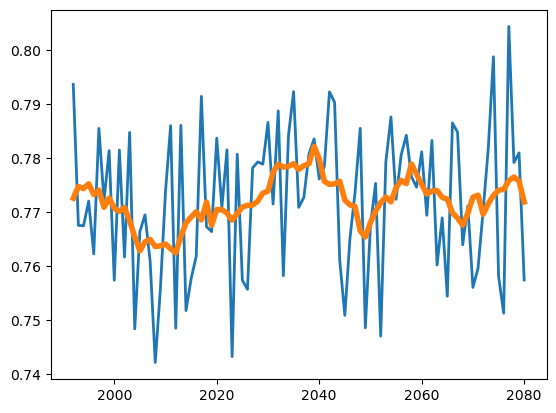

In [7]:
df = rainfall_events_all_df

# 2. Compute mean saturation per HC class per year
class_year_sat = (df.groupby(["HC_status", "start_year"], observed=True)["sat_at_peak"].mean().reset_index())

# 3. Fixed reference weights = share of events in each HC class in a baseline period
baseline_years = df["start_year"] <= df["start_year"].min() + 10
baseline_weights = (df[baseline_years]["HC_status"].value_counts(normalize=True))

# 4. Standardized series: each year, apply BASELINE weights to that year's class means
standardized = (class_year_sat.pivot(index="start_year", columns="HC_status", values="sat_at_peak")
    .mul(baseline_weights, axis=1).sum(axis=1))

rolling_standardized =standardized.rolling(window=10,center=True, min_periods=5).mean()

slope_std, intercept_std, r3, p3, se3 = linregress(standardized.index, standardized.values)
print(f"Composition-standardized trend: {slope_std:.5f}/yr (p={p3:.3f})")

plt.plot(standardized.index,standardized,linewidth=2)
plt.plot(rolling_standardized.index,rolling_standardized,linewidth=4)

In [10]:
class_year_sat

,HC_status,start_year,sat_at_peak
0,D,1992,0.922809
1,D,1993,0.885375
2,D,1994,0.897645
3,D,1995,0.908424
4,D,1996,0.894953
...,...,...,...
351,A,2076,0.883338
352,A,2077,0.894818
353,A,2078,0.910097
354,A,2079,0.847375


In [117]:
import statsmodels.formula.api as smf

model = smf.ols( "sat_at_peak ~ start_year + hc_at_peak + start_year:hc_at_peak",data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            sat_at_peak   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     10.56
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          2.93e-276
Time:                        10:10:13   Log-Likelihood:                 31675.
No. Observations:               84431   AIC:                        -6.299e+04
Df Residuals:                   84253   BIC:                        -6.133e+04
Df Model:                         177                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### Get spatial data and add regional geometries to rainfall data

In [110]:
rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

quantiles = [0.1, 0.3, 0.6, 0.9, 1, 2, 3]  
q0 = 0  # lower bound, adjust if needed
bins = [-float('inf')] + quantiles + [float('inf')]
n_classes = len(bins) - 1
n_classes = len(quantiles) + 1

# Auto-generate labels from bin edges (reversed to match flipped class order)
edges = [q0] + quantiles + [np.inf]
class_labels = [f"{edges[i]}–{edges[i+1]}" for i in range(len(edges)-1)][::-1]


import string
labels=class_labels[::-1]
rainfall_events_all_df['HC_status_2'] = pd.cut( rainfall_events_all_df['hc_at_peak'], bins=bins, labels=labels, 
                                               right=False, include_lowest=True)

In [51]:
regions = rainfall_events_all_df.loc[~rainfall_events_all_df["HC_status_2"].map(lambda x: isinstance(x, (int, float))), "HC_status_2"].unique()
regions = ['0–0.1', '0.1–0.3', '0.3–0.6', '0.6–0.9','0.9–1','1–2',   '2–3', '3–inf']

In [94]:
# np.nanmax(rainfall_events_all_df['sat_at_peak'])
# list(rainfall_events_all_df.columns)

In [95]:
def make_plots_saturation(df, axs, row_num, region):

    annual_mean_rainfall_intensity = (df.groupby("start_year", observed=True)["fu_at_peak"].mean())
    rolling_rainfall_intensity =annual_mean_rainfall_intensity.rolling(window=5,center=True, min_periods=5).mean()
    
    # --------------------------------------------------
    # Column 1: Event frequency
    # --------------------------------------------------
   
    slope, intercept, r_value, p_value, std_err = linregress(annual_mean_rainfall_intensity.index,
                                                             annual_mean_rainfall_intensity.values)
    trend = intercept + slope * annual_mean_rainfall_intensity.index
    axs[row_num].plot(rolling_rainfall_intensity.index,rolling_rainfall_intensity,linewidth=2)
    axs[row_num].plot(annual_mean_rainfall_intensity.index,annual_mean_rainfall_intensity.values)# ,marker="o")
    axs[row_num].plot(annual_mean_rainfall_intensity.index,trend,linestyle="-",linewidth=5,
                        label=f"Trend: {slope:+.2f} mm/hr/yr, p={p_value:.3f}")
    axs[row_num].set_ylabel(region, fontsize=15)
    axs[row_num].grid(alpha=0.2)       
    # axs[row_num].legend()

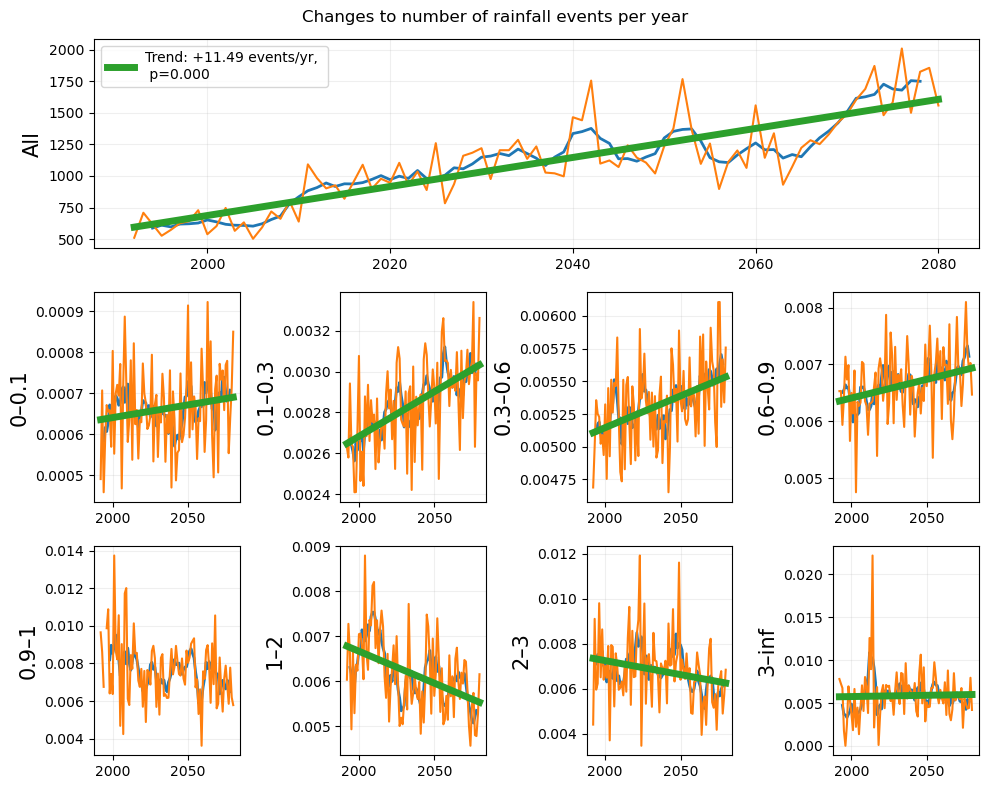

In [121]:
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(1 + int(np.ceil(len(regions) / 4)), 4)

ax_all = fig.add_subplot(gs[0, :])
make_plots(rainfall_events_all_df, [ax_all], 0, "All")

for row_num, region in enumerate(regions):
    row = row_num // 4 + 1
    col = row_num % 4
    ax = fig.add_subplot(gs[row, col])
    
    one_region = rainfall_events_all_df[rainfall_events_all_df["HC_status_2"] == region]
    make_plots_saturation(one_region, [ax], 0, region)
    
fig.suptitle("Changes to number of rainfall events per year")  
fig.tight_layout()

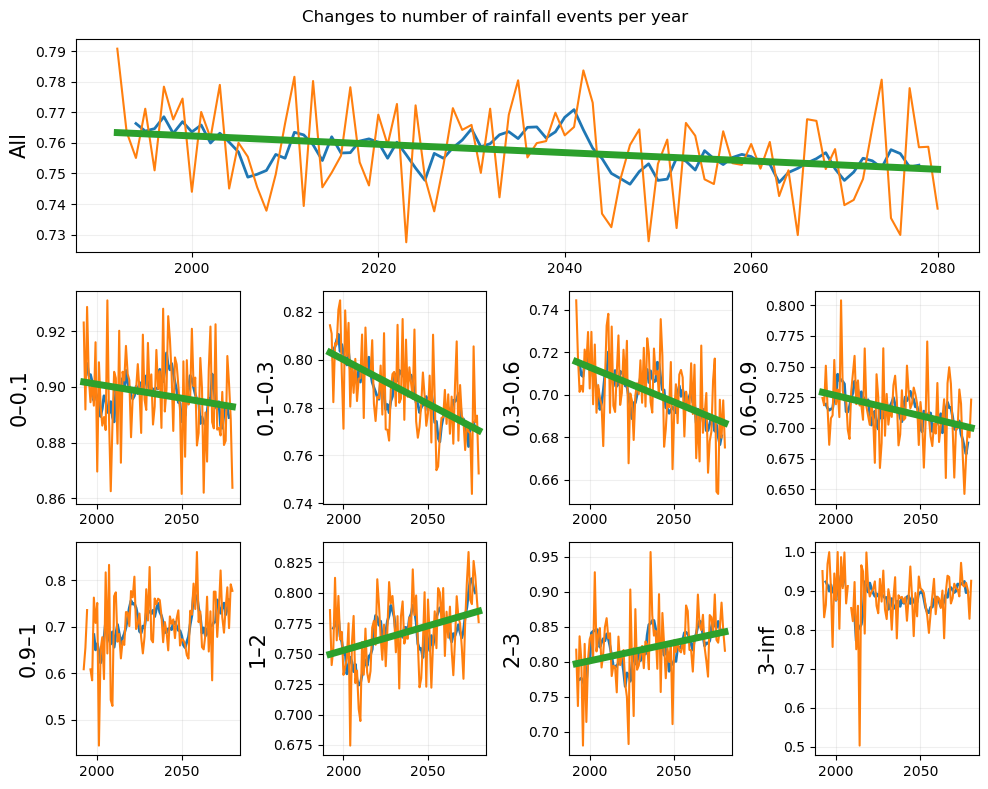

In [93]:
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(1 + int(np.ceil(len(regions) / 4)), 4)

ax_all = fig.add_subplot(gs[0, :])
make_plots_saturation(rainfall_events_all_df, [ax_all], 0, "All")

for row_num, region in enumerate(regions):
    row = row_num // 4 + 1
    col = row_num % 4
    ax = fig.add_subplot(gs[row, col])
    
    one_region = rainfall_events_all_df[rainfall_events_all_df["HC_status_2"] == region]
    make_plots_saturation(one_region, [ax], 0, region)
    
fig.suptitle("Changes to number of rainfall events per year")  
fig.tight_layout()

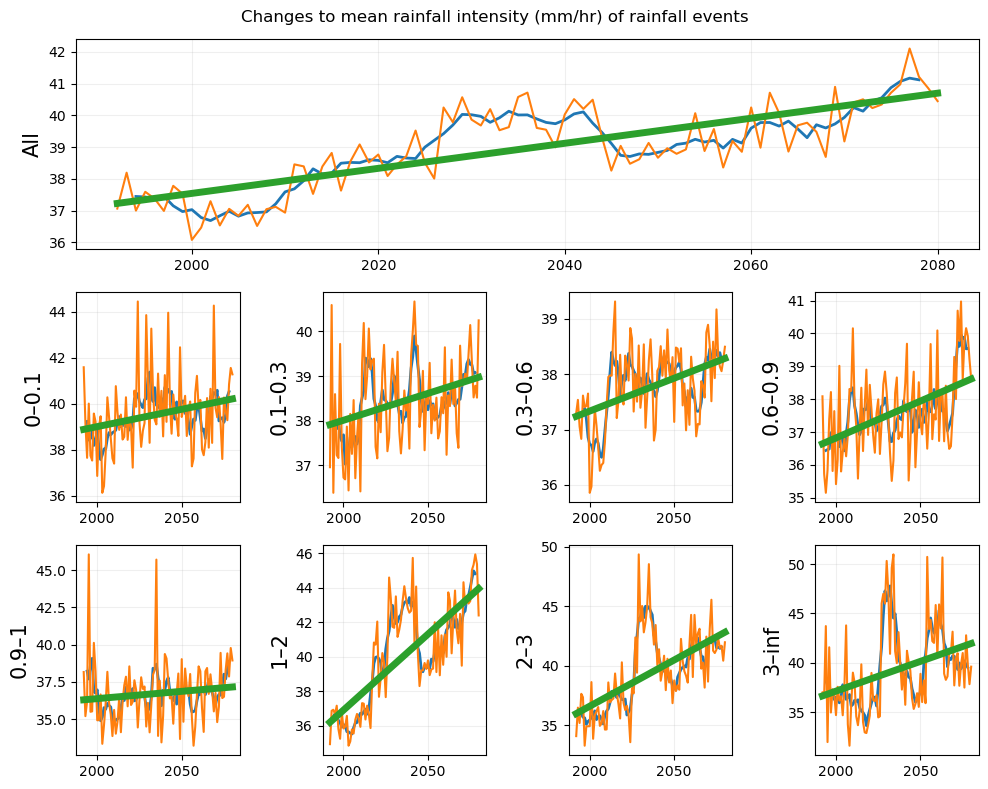

In [42]:
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(1 + int(np.ceil(len(regions) / 4)), 4)

ax_all = fig.add_subplot(gs[0, :])
make_plots_intensity(rainfall_events_all_df, [ax_all], 0, "All")

for row_num, region in enumerate(regions):
    row = row_num // 4 + 1
    col = row_num % 4
    ax = fig.add_subplot(gs[row, col])
    
    one_region = rainfall_events_all_df[rainfall_events_all_df["HC_status_2"] == region]
    make_plots_intensity(one_region, [ax], 0, region)
    
fig.suptitle("Changes to mean rainfall intensity (mm/hr) of rainfall events")  
fig.tight_layout()

### Changes to flood severity?

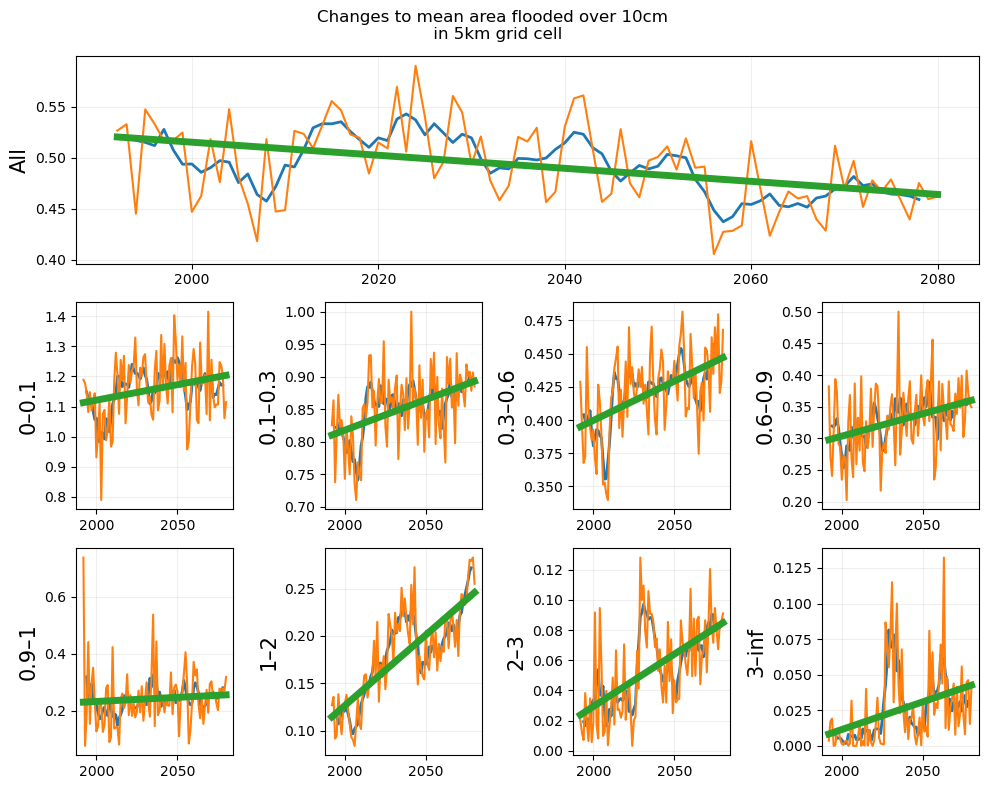

In [44]:
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(1 + int(np.ceil(len(regions) / 4)), 4)

ax_all = fig.add_subplot(gs[0, :])
make_plots_flood(rainfall_events_all_df, [ax_all], 0, "All")

for row_num, region in enumerate(regions):
    row = row_num // 4 + 1
    col = row_num % 4
    ax = fig.add_subplot(gs[row, col])# , sharey=ax_all)
    
    one_region = rainfall_events_all_df[rainfall_events_all_df["HC_status_2"] == region]
    make_plots_flood(one_region, [ax], 0, region)

fig.suptitle("Changes to mean area flooded over 10cm \n in 5km grid cell")    
fig.tight_layout()

### Elasticity

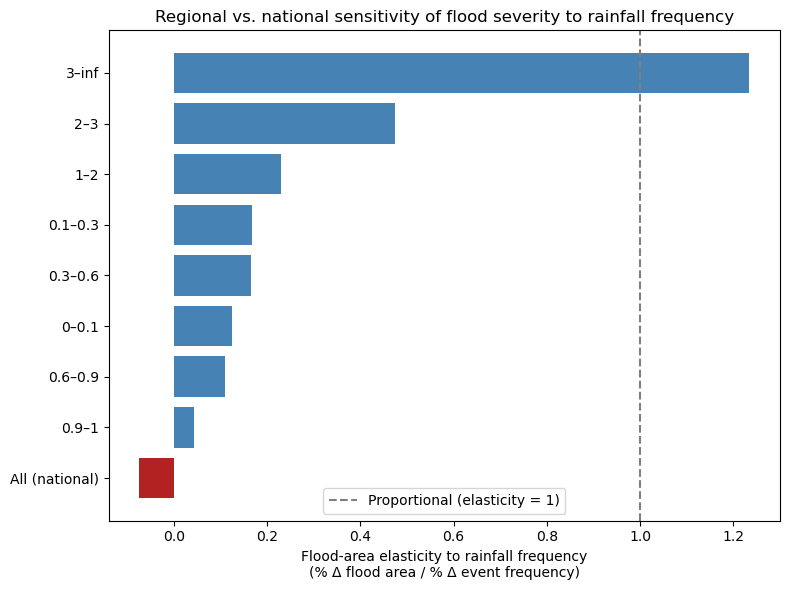

In [45]:
df = rainfall_events_all_df

# Assumes a region column — adjust name to whatever you're using
# e.g. 'region', 'georegion', 'admin_region'
REGION_COL = "HC_status_2"

# --------------------------------------------------
# Frequency, intensity, and flood severity trends by region
# --------------------------------------------------
freq_trends = regional_trends(df, REGION_COL, None, "count", "frequency")
intensity_trends = regional_trends(df, REGION_COL, "max_precip", "mean", "intensity")
flood_trends = regional_trends(df, REGION_COL, "10cm_area", "mean", "flood_severity")

# --------------------------------------------------
# Merge and compute elasticities
# --------------------------------------------------
elasticity_df = (
    freq_trends[[REGION_COL, "pct_change"]].rename(columns={"pct_change": "pct_change_freq"})
    .merge(intensity_trends[[REGION_COL, "pct_change"]].rename(columns={"pct_change": "pct_change_intensity"}), on=REGION_COL)
    .merge(flood_trends[[REGION_COL, "pct_change"]].rename(columns={"pct_change": "pct_change_flood"}), on=REGION_COL))

elasticity_df["elasticity_freq"] = elasticity_df["pct_change_flood"] / elasticity_df["pct_change_freq"]
elasticity_df["elasticity_intensity"] = elasticity_df["pct_change_flood"] / elasticity_df["pct_change_intensity"]

elasticity_df = elasticity_df.sort_values("elasticity_freq")

# --------------------------------------------------
# National ("All") elasticity, computed the same way
# --------------------------------------------------
national_freq = df.groupby("start_year", observed=True).size().rename("frequency").reset_index()
national_intensity = df.groupby("start_year", observed=True)["max_precip"].mean().rename("intensity").reset_index()
national_flood = df.groupby("start_year", observed=True)["10cm_area"].mean().rename("flood_severity").reset_index()

national_freq_trend = fit_trend(national_freq["start_year"].values, national_freq["frequency"].values)
national_intensity_trend = fit_trend(national_intensity["start_year"].values, national_intensity["intensity"].values)
national_flood_trend = fit_trend(national_flood["start_year"].values, national_flood["flood_severity"].values)

national_row = pd.DataFrame([{
    REGION_COL: "All (national)",
    "pct_change_freq": national_freq_trend["pct_change"],
    "pct_change_intensity": national_intensity_trend["pct_change"],
    "pct_change_flood": national_flood_trend["pct_change"],
}])
national_row["elasticity_freq"] = national_row["pct_change_flood"] / national_row["pct_change_freq"]
national_row["elasticity_intensity"] = national_row["pct_change_flood"] / national_row["pct_change_intensity"]

# Combine with regional results
elasticity_df_all = pd.concat([elasticity_df, national_row], ignore_index=True).sort_values("elasticity_freq")

# --------------------------------------------------
# Plot with "All" highlighted separately
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["firebrick" if r == "All (national)" else "steelblue" for r in elasticity_df_all[REGION_COL]]
ax.barh(elasticity_df_all[REGION_COL], elasticity_df_all["elasticity_freq"], color=colors)
ax.axvline(1, color="grey", linestyle="--", label="Proportional (elasticity = 1)")
ax.set_xlabel("Flood-area elasticity to rainfall frequency\n(% Δ flood area / % Δ event frequency)")
ax.set_title("Regional vs. national sensitivity of flood severity to rainfall frequency")
ax.legend()
plt.tight_layout()

In [96]:
# fig, ax = plt.subplots(figsize=(12, 6))

# for region, group in annual_region_counts.groupby("geo_region"):
#     ax.plot(group["start_year"],group["n_events"],label=region)

# ax.set_xlabel("Year")
# ax.set_ylabel("Number of rainfall events")
# ax.set_title("Annual rainfall-event frequency by region")

# ax.legend(bbox_to_anchor=(1.02, 1),loc="upper left")

# plt.tight_layout()
# plt.show()

In [21]:
# # Calculate counts for each region and period
# region_counts = (df.groupby(["geo_region", "period"], observed=True).size().reset_index(name="n_events"))
# # change format so two time periods are side by side
# region_counts_comparison = (region_counts.pivot(index="geo_region", columns="period",values=["n_events"]))
# # Find change between two periods
# change = pd.DataFrame(index=region_counts_comparison.index)
# change["n_events_%"] = ((region_counts_comparison["n_events"]["2060–2080"] / region_counts_comparison["n_events"]["2000–2020"]) - 1) * 100

In [34]:
# region_counts_comparison["n_events_%"] = ((region_counts_comparison["n_events"]["2060–2080"] 
#                                            / region_counts_comparison["n_events"]["2000–2020"]) - 1) * 100
# region_counts_comparison

In [46]:
# # Calculate mean values for each region and period
# region_means = (df.groupby(["geo_region", "period"], observed=True)[["max_precip", "10cm_area"]].mean().reset_index())

# region_comparison = (region_means.pivot(index="geo_region", columns="period",values=["max_precip", "10cm_area"]))

# change = pd.DataFrame(index=region_comparison.index)

# change["max_precip_%"] = ((region_comparison["max_precip"]["2060–2080"] / region_comparison["max_precip"]["2000–2020"]) - 1) * 100

# change["10cm_area_%"] = ((region_comparison["10cm_area"]["2060–2080"] / region_comparison["10cm_area"]["2000–2020"]) - 1) * 100

In [45]:

# # Get one polygon for each region
# region_geometries = (df[["geo_region", "region_geometry"]].drop_duplicates("geo_region")
#                      .rename(columns={"region_geometry": "geometry"}))

# # Turn it into a GeoDataFrame
# region_geometries = gpd.GeoDataFrame(region_geometries,geometry="geometry",crs=rainfall_events_all_df.crs)

# # Join the calculated changes to the polygons
# region_change_gdf = region_geometries.merge(change,on="geo_region",how="left")
# region_change_gdf

### Do number of events increase in each region?

### Does the severity of events get worse?

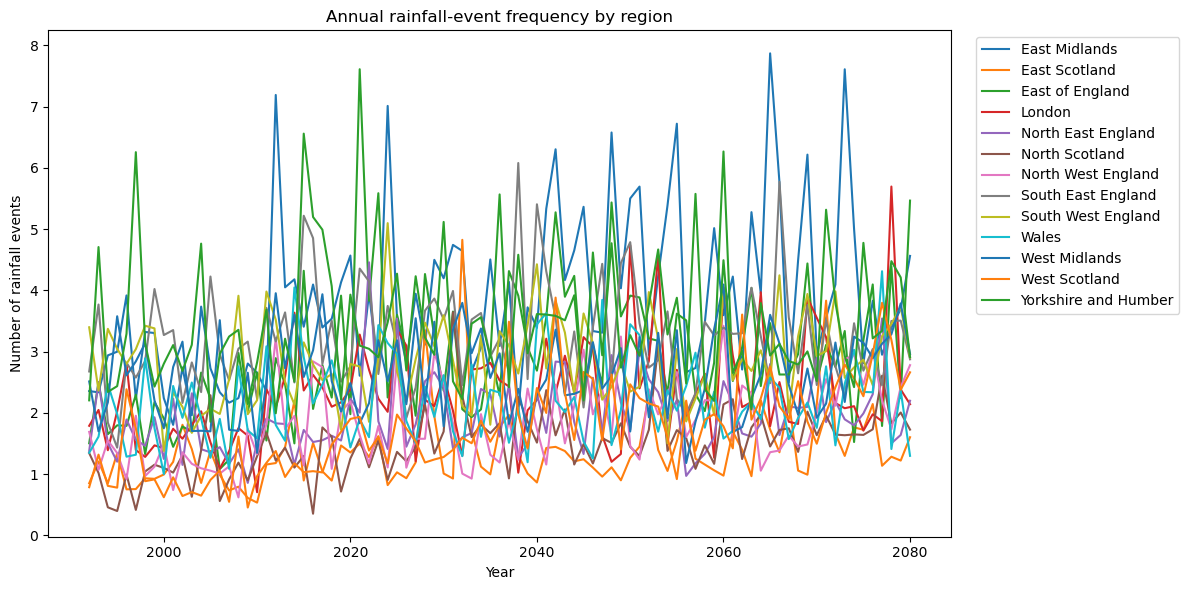

In [50]:
annual_severity = (
    rainfall_events_all_df
    .groupby(["geo_region", "start_year"], observed=True)
    ["10cm_area"]
    .mean()
    .reset_index()
)
annual_median = (
    rainfall_events_all_df
    .groupby(["geo_region", "start_year"], observed=True)
    ["10cm_area"]
    .median()
    .reset_index()
)
annual_max = (
    rainfall_events_all_df
    .groupby(["geo_region", "start_year"], observed=True)
    ["10cm_area"]
    .max()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(12, 6))

for region, group in annual_max.groupby("geo_region"):
    ax.plot(
        group["start_year"],
        group["10cm_area"],
        label=region
    )

ax.set_xlabel("Year")
ax.set_ylabel("Number of rainfall events")
ax.set_title("Annual rainfall-event frequency by region")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

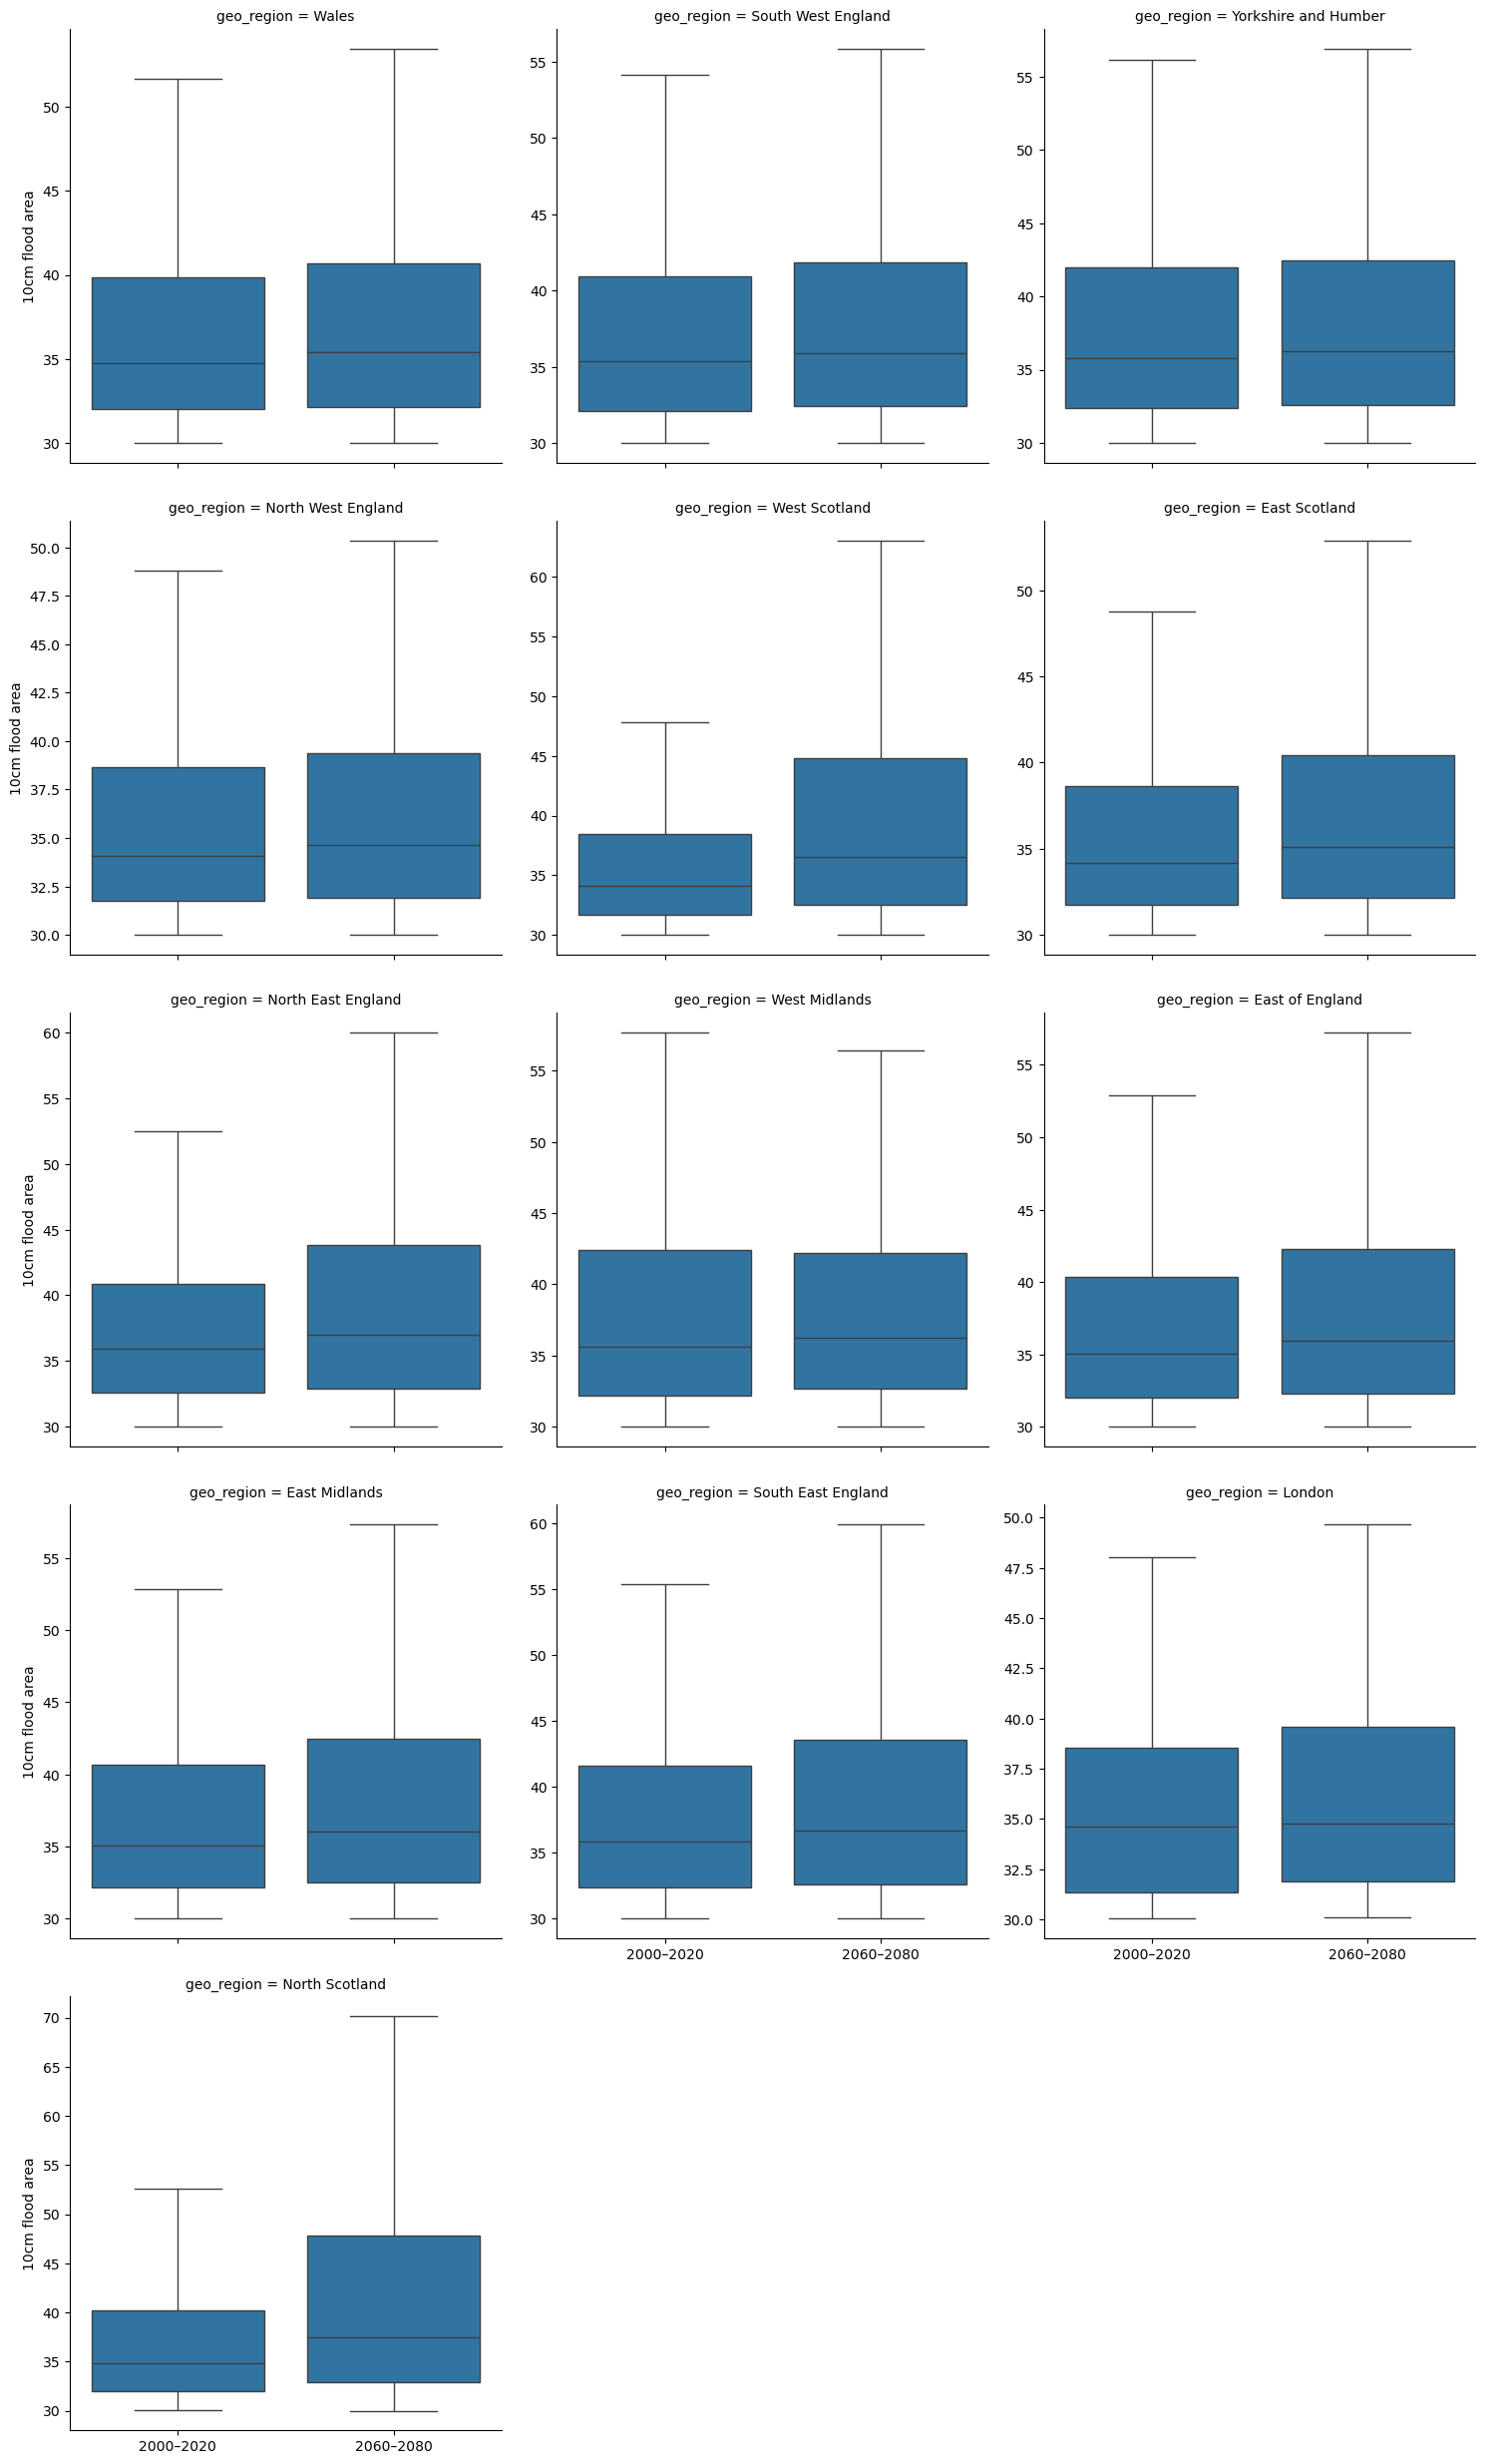

In [57]:
df_plot = rainfall_events_all_df[
    rainfall_events_all_df["start_year"].between(2000, 2020) |
    rainfall_events_all_df["start_year"].between(2060, 2080)
].copy()

df_plot["period"] = np.where(
    df_plot["start_year"].between(2000, 2020),
    "2000–2020",
    "2060–2080"
)

import seaborn as sns

g = sns.catplot(
    data=df_plot,
    x="period",
    y="max_precip",
    col="geo_region",
    col_wrap=3,
    kind="box",
    sharey=False,
    showfliers=False
)

g.set_axis_labels("", "10cm flood area")

/tmp/ipykernel_23327/3217876626.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for period, group in df.groupby("period"):


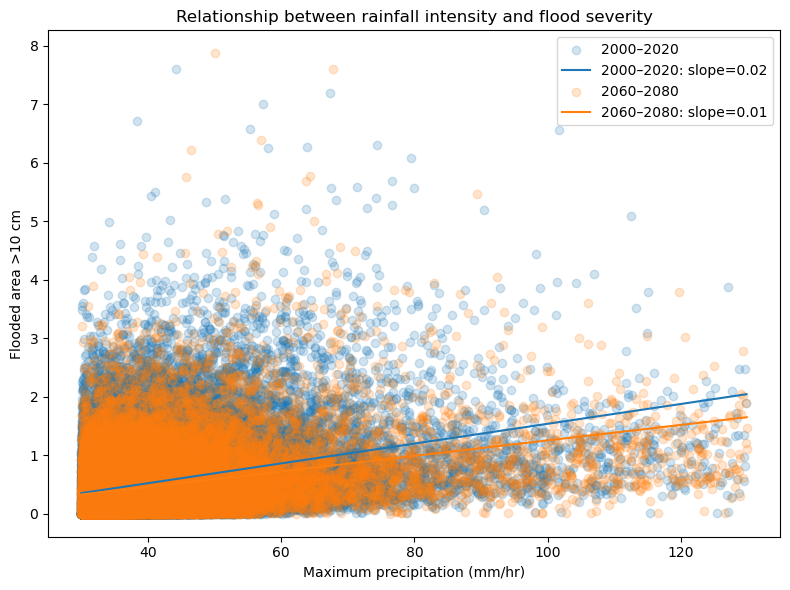

In [64]:
df = df.dropna(subset=["period", "max_precip", "10cm_area"])
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))

for period, group in df.groupby("period"):

    x = group["max_precip"].values
    y = group["10cm_area"].values

    ax.scatter(
        x,
        y,
        alpha=0.2,
        label=period
    )

    slope, intercept, r, p, se = linregress(x, y)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line

    ax.plot(
        x_line,
        y_line,
        label=f"{period}: slope={slope:.2f}"
    )

ax.set_xlabel("Maximum precipitation (mm/hr)")
ax.set_ylabel("Flooded area >10 cm")
ax.set_title("Relationship between rainfall intensity and flood severity")
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_23327/3131292524.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for period, group in region_df.groupby("period"):
/tmp/ipykernel_23327/3131292524.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for period, group in region_df.groupby("period"):
/tmp/ipykernel_23327/3131292524.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for period, group in region_df.groupby("period"):
/tmp/ipykernel_2332

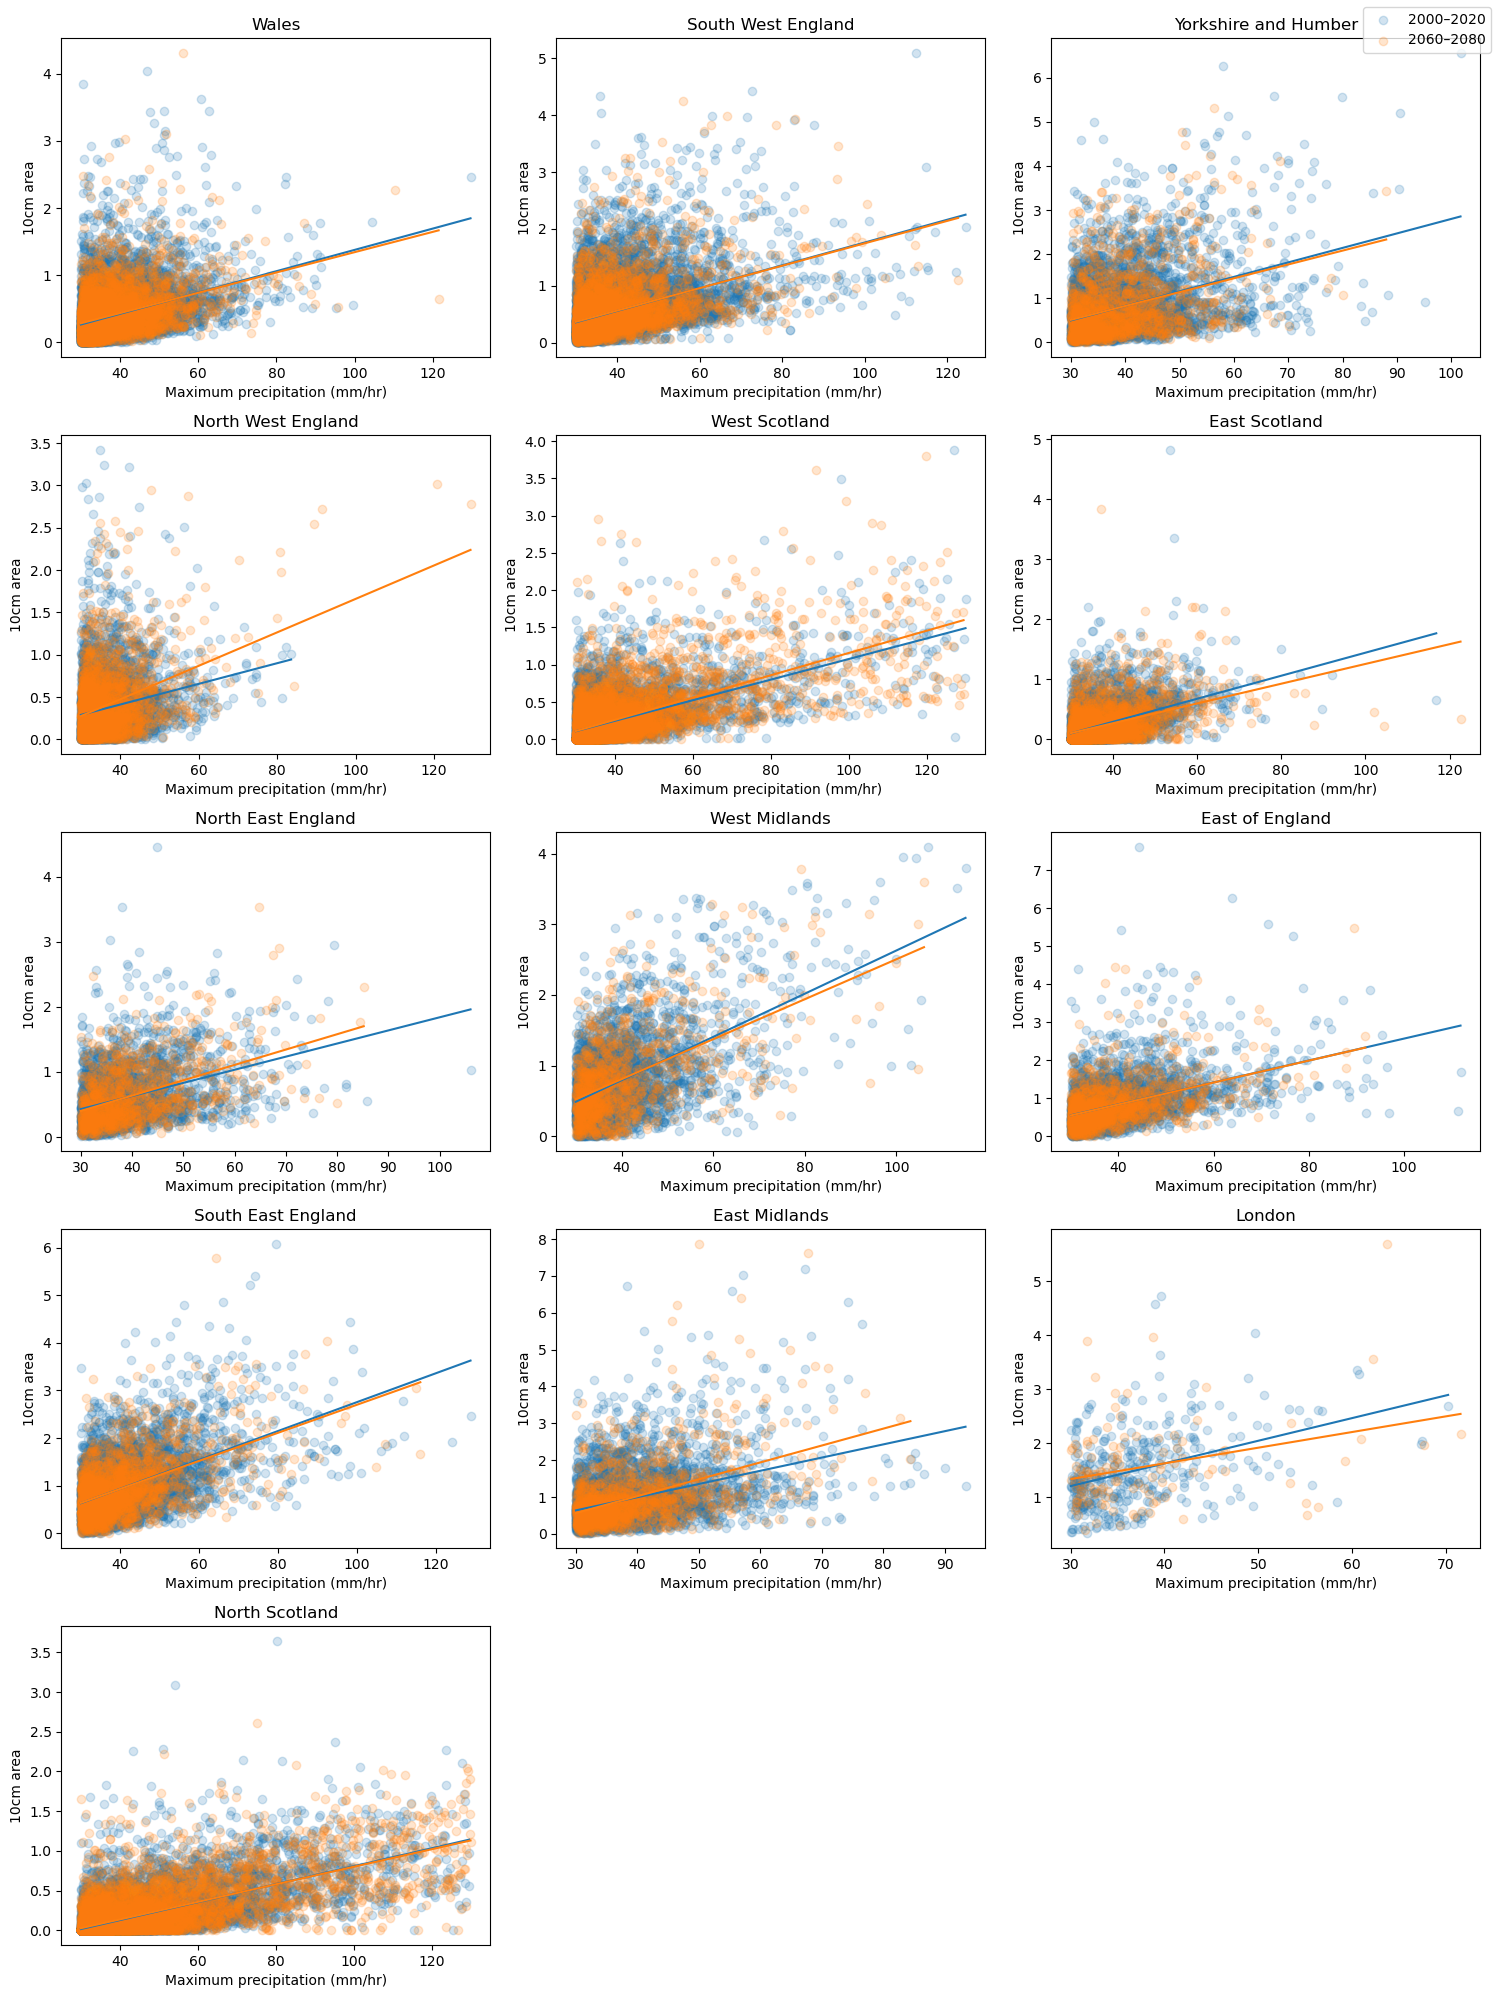

In [65]:
regions = df["geo_region"].dropna().unique()

fig, axes = plt.subplots(
    nrows=int(np.ceil(len(regions) / 3)),
    ncols=3,
    figsize=(15, 4 * int(np.ceil(len(regions) / 3)))
)

axes = np.atleast_1d(axes).flatten()

for ax, region in zip(axes, regions):

    region_df = df[df["geo_region"] == region]

    for period, group in region_df.groupby("period"):

        ax.scatter(
            group["max_precip"],
            group["10cm_area"],
            alpha=0.2,
            label=period
        )

        if len(group) > 2:

            slope, intercept, r, p, se = linregress(
                group["max_precip"],
                group["10cm_area"]
            )

            x_line = np.linspace(
                group["max_precip"].min(),
                group["max_precip"].max(),
                100
            )

            ax.plot(
                x_line,
                intercept + slope * x_line
            )

    ax.set_title(region)
    ax.set_xlabel("Maximum precipitation (mm/hr)")
    ax.set_ylabel("10cm area")

# Remove unused axes
for ax in axes[len(regions):]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels)

plt.tight_layout()
plt.show()

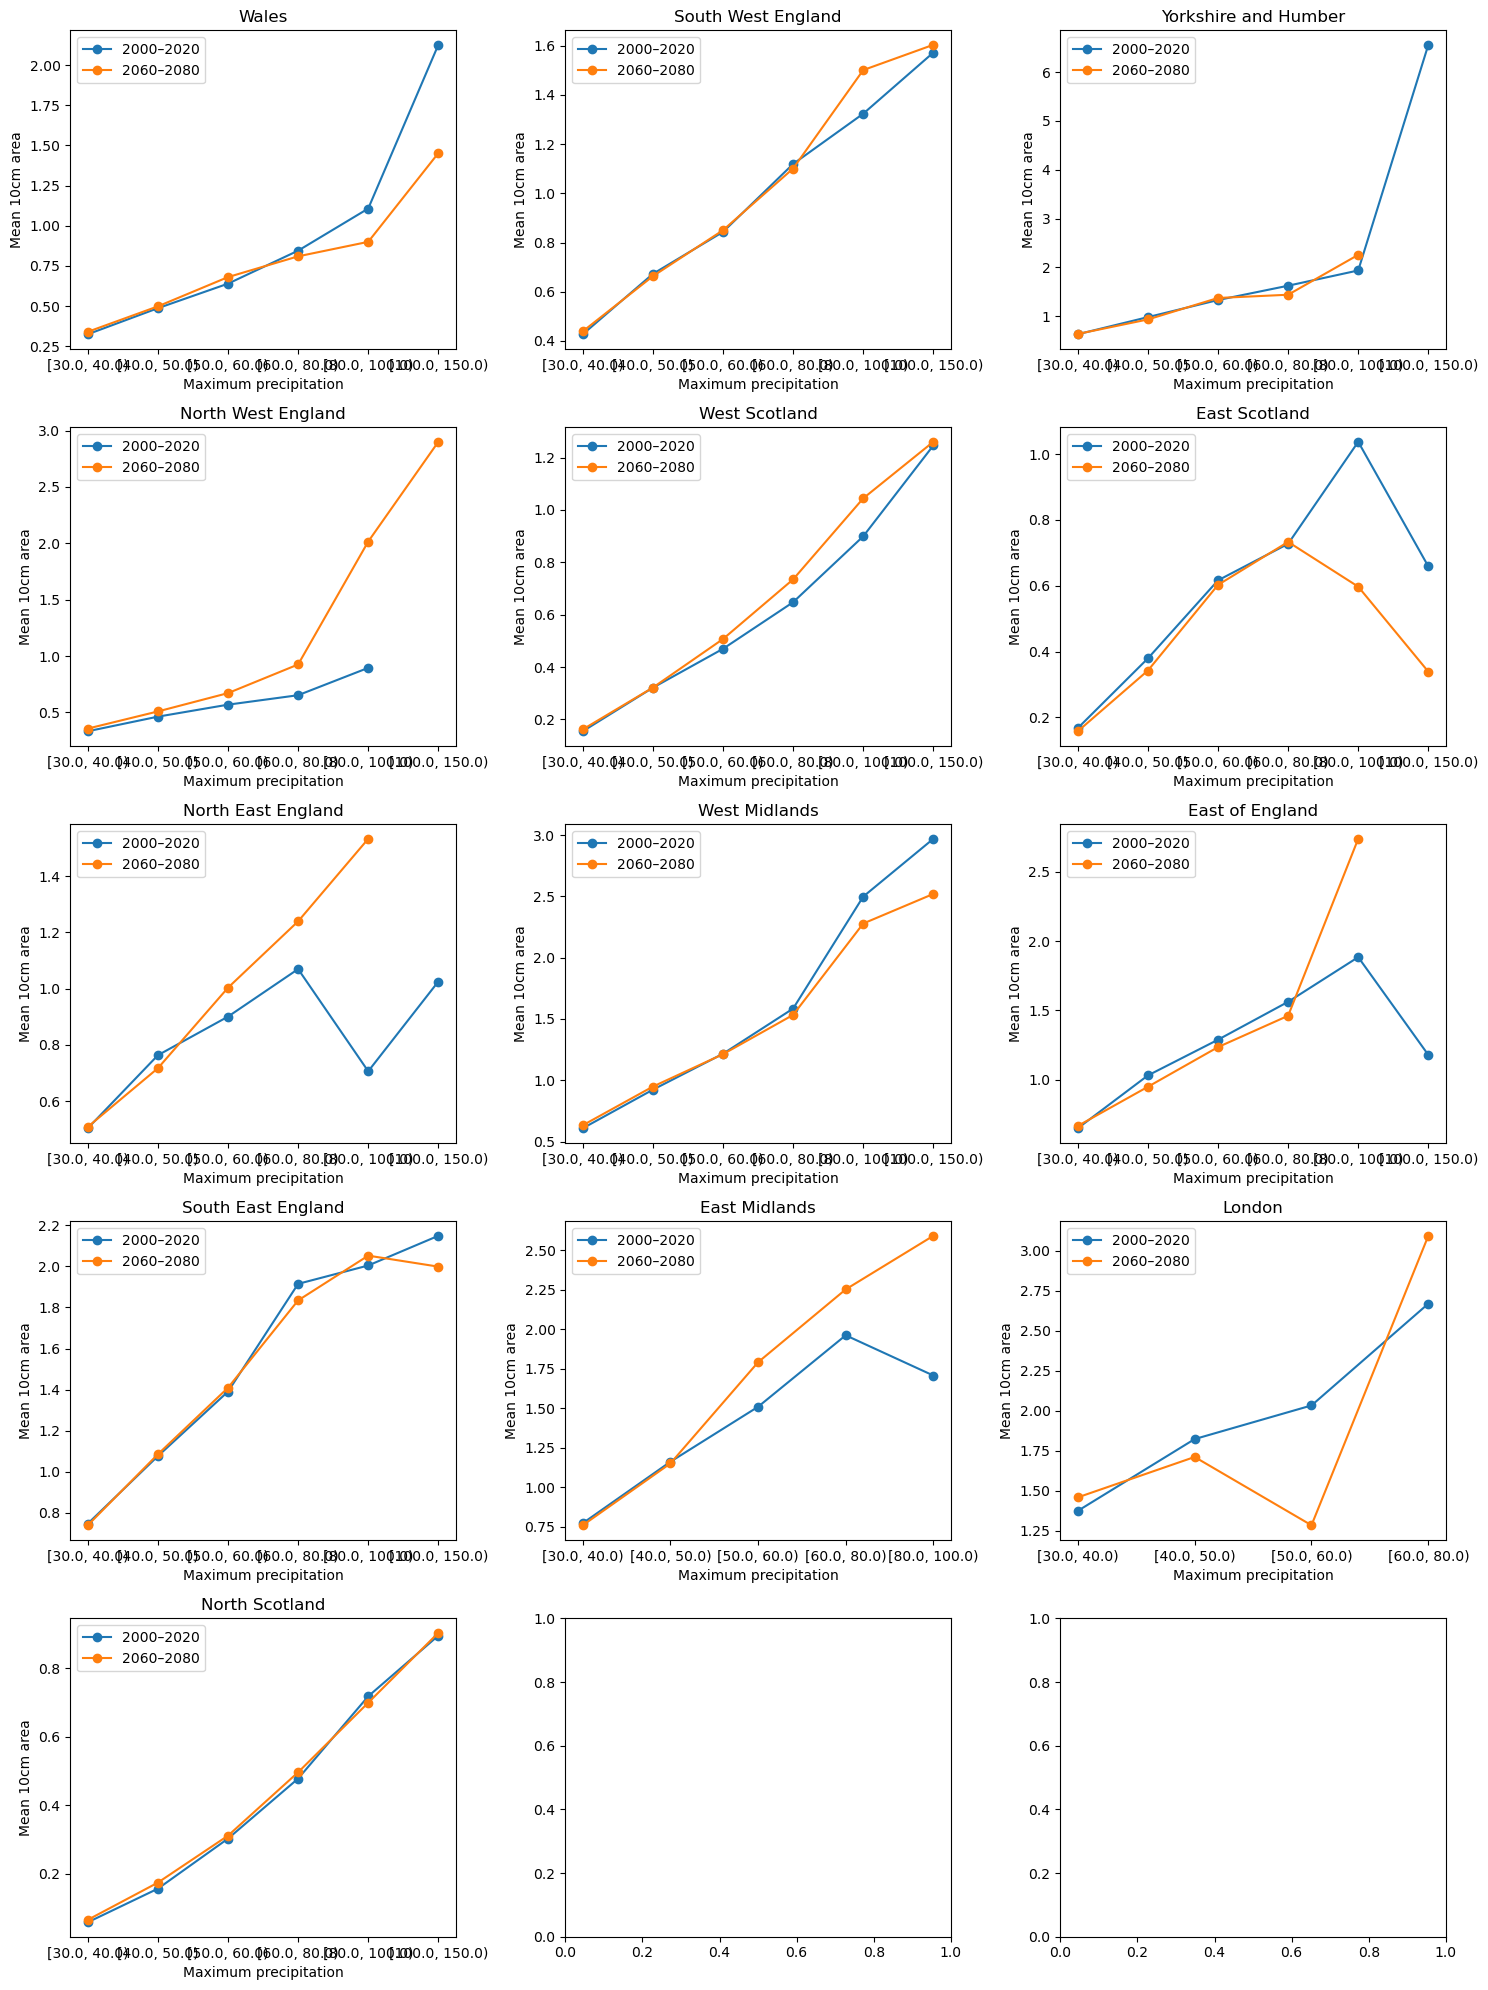

In [77]:
bins = [30, 40, 50, 60, 80, 100, 150, np.inf]

df["rain_bin"] = pd.cut(
    df["max_precip"],
    bins=bins,
    right=False
)

binned = (
    df.groupby(
        ["geo_region", "period", "rain_bin"],
        observed=True
    )["10cm_area"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

fig, axes = plt.subplots(
    nrows=int(np.ceil(len(regions) / 3)),
    ncols=3,
    figsize=(15, 4 * int(np.ceil(len(regions) / 3)))
)

axes = np.atleast_1d(axes).flatten()

for ax, region in zip(axes, regions):

    plot_df = binned[
        binned["geo_region"] == region]


    for period, group in plot_df.groupby("period",observed=False):

        ax.plot(
            group["rain_bin"].astype(str),
            group["mean"],
            marker="o",
            label=period)

    ax.set_xlabel("Maximum precipitation")
    ax.set_ylabel("Mean 10cm area")
    ax.set_title(region)

    ax.legend()

#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

fig.tight_layout()

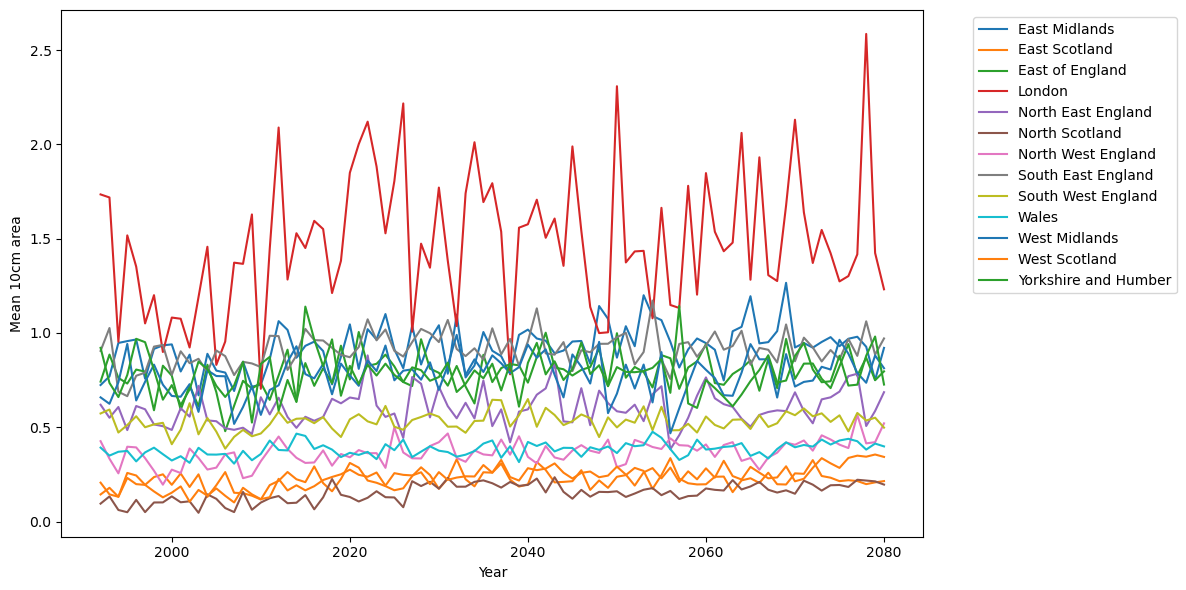

In [35]:
annual_region = (
    rainfall_events_all_df
    .groupby(["geo_region", "start_year"], observed=True)["10cm_area"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

for region, group in annual_region.groupby("geo_region"):
    ax.plot(
        group["start_year"],
        group["10cm_area"],
        label=region
    )

ax.set_ylabel("Mean 10cm area")
ax.set_xlabel("Year")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

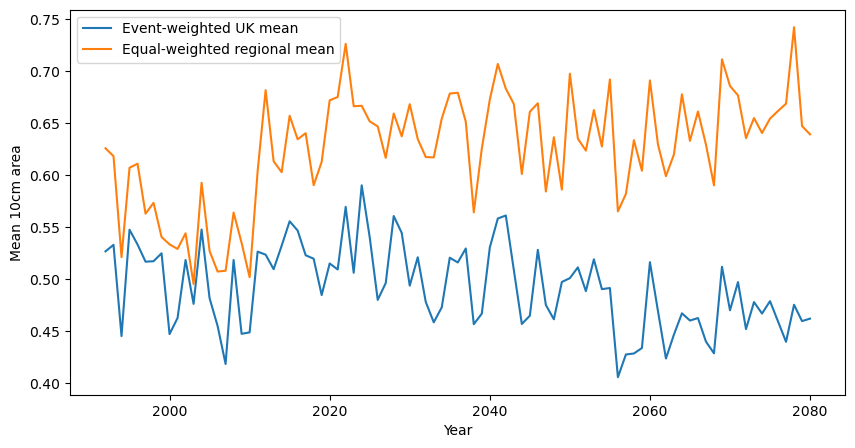

In [40]:
uk_mean = (
    rainfall_events_all_df
    .groupby("start_year")["10cm_area"]
    .mean()
)

regional_annual = (
    rainfall_events_all_df
    .groupby(
        ["start_year", "geo_region"],
        observed=True
    )["10cm_area"]
    .mean()
)

equal_weighted_uk = (
    regional_annual
    .groupby("start_year")
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    uk_mean.index,
    uk_mean.values,
    label="Event-weighted UK mean"
)

ax.plot(
    equal_weighted_uk.index,
    equal_weighted_uk.values,
    label="Equal-weighted regional mean"
)

ax.legend()
ax.set_ylabel("Mean 10cm area")
ax.set_xlabel("Year")

plt.show()

In [3]:
annual_mean_flood_severity = (rainfall_events_all_df.groupby("start_year", observed=True)["10cm_area"].mean())
annual_mean_rainfall_intensity = (rainfall_events_all_df.groupby("start_year", observed=True)["max_precip"].mean())
annual_mean_rainfall_accum = (rainfall_events_all_df.groupby("start_year", observed=True)["total_acc"].mean())
annual_counts = (rainfall_events_all_df.groupby(["start_year"],observed=True)).size()
annual_severity = (rainfall_events_all_df.groupby(["start_year"], observed=True)["10cm_area"].sum())

### Is frequency of rainfall events over 30mm/hr increasing

Slope: 11.933 events/year
R²: 0.710
p-value: 0.0000


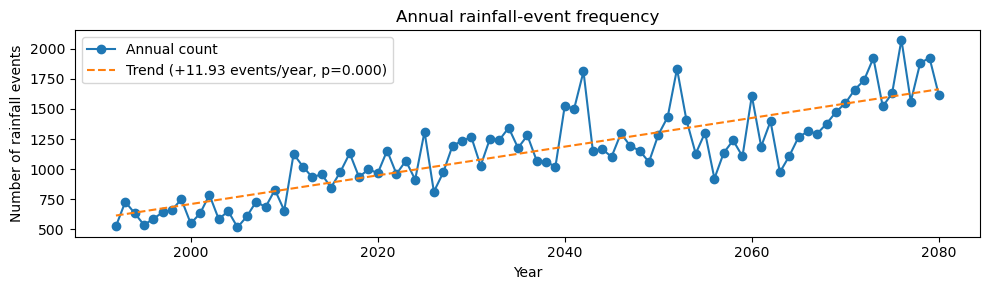

In [7]:
# Fit linear trend
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(annual_counts.index,annual_counts.values)
trend = intercept + slope * annual_counts.index

print(f"Slope: {slope:.3f} events/year")
print(f"R²: {r_value**2:.3f}")
print(f"p-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 3))

# Event frequency
ax.plot(annual_counts.index,annual_counts.values,marker="o",label="Annual count")

# Trend line
# ax.plot(annual_counts.index,trend(annual_counts.index),linestyle="--",label="Linear trend")
ax.plot(annual_counts.index,trend,linestyle="--",label=f"Trend ({slope:+.2f} events/year, p={p_value:.3f})")

ax.set_ylabel("Number of rainfall events")
ax.set_xlabel("Year")
ax.set_title("Annual rainfall-event frequency")
ax.legend()

plt.tight_layout()
plt.show()

### Is severity of of events (over 30mm/hr) increasing

In [71]:
# 10-year rolling mean
rolling_rainfall_intensity =annual_mean_rainfall_intensity.rolling(window=10,center=True, min_periods=5).mean()
rolling_flood_severity =annual_mean_flood_severity.rolling(window=10,center=True, min_periods=5).mean()

Slope: 11.933 events/year
R²: 0.710
p-value: 0.0000


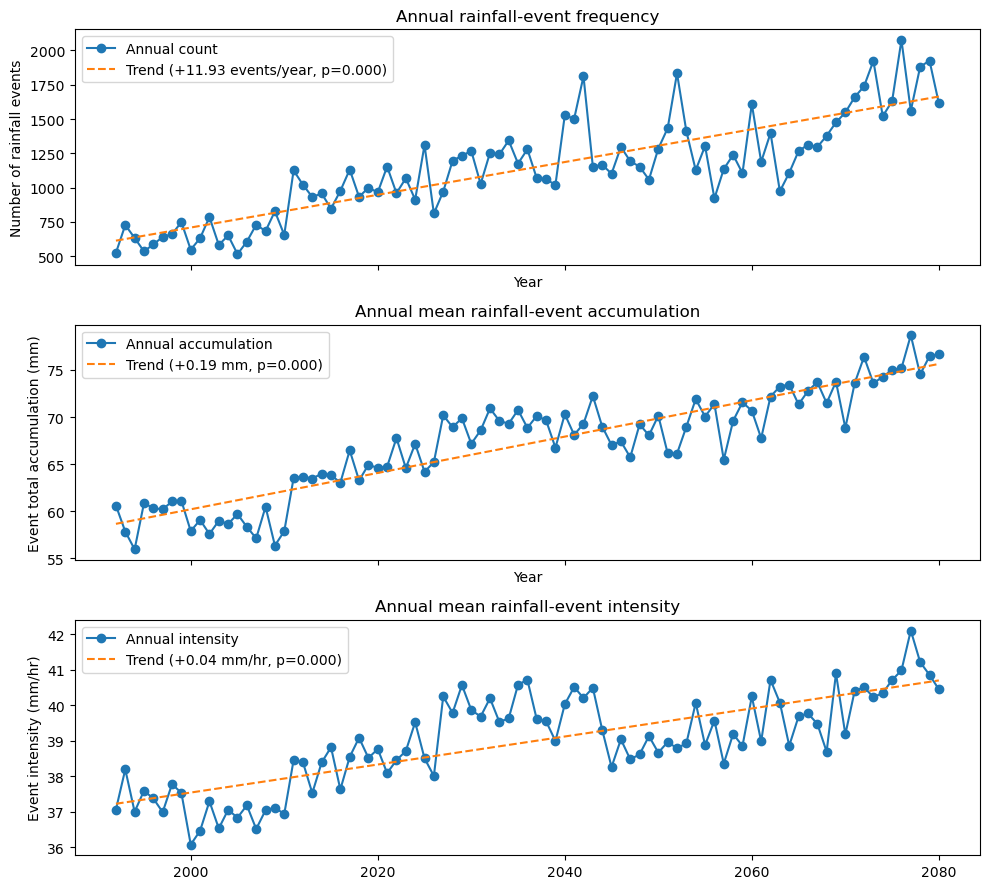

In [20]:
# Fit linear trend
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(annual_counts.index,annual_counts.values)
trend = intercept + slope * annual_counts.index

print(f"Slope: {slope:.3f} events/year")
print(f"R²: {r_value**2:.3f}")
print(f"p-value: {p_value:.4f}")

fig, axs = plt.subplots(nrows = 3, figsize=(10, 9), sharex=True)

# Event frequency
axs[0].plot(annual_counts.index,annual_counts.values,marker="o",label="Annual count")

# Trend line
axs[0].plot(annual_counts.index,trend,linestyle="--",label=f"Trend ({slope:+.2f} events/year, p={p_value:.3f})")

axs[0].set_ylabel("Number of rainfall events")
axs[0].set_xlabel("Year")
axs[0].set_title("Annual rainfall-event frequency")
axs[0].legend()

######
slope, intercept, r_value, p_value, std_err = linregress(annual_mean_rainfall_accum.index,annual_mean_rainfall_accum.values)
trend = intercept + slope * annual_counts.index


# Event frequency
axs[1].plot(annual_mean_rainfall_accum.index, annual_mean_rainfall_accum.values,marker="o",label="Annual accumulation")

# Trend line
axs[1].plot(annual_mean_rainfall_accum.index,trend,linestyle="--",label=f"Trend ({slope:+.2f} mm, p={p_value:.3f})")

axs[1].set_ylabel("Event total accumulation (mm)")
axs[1].set_xlabel("Year")
axs[1].set_title("Annual mean rainfall-event accumulation")
axs[1].legend()

###########
slope, intercept, r_value, p_value, std_err = linregress(annual_mean_rainfall_intensity.index,annual_mean_rainfall_intensity.values)
trend = intercept + slope * annual_counts.index

# Event frequency
axs[2].plot(annual_mean_rainfall_intensity.index, annual_mean_rainfall_intensity.values,marker="o",label="Annual intensity")

# Trend line
axs[2].plot(annual_mean_rainfall_intensity.index,trend,linestyle="--",label=f"Trend ({slope:+.2f} mm/hr, p={p_value:.3f})")

axs[2].set_ylabel("Event intensity (mm/hr)")
axs[2].set_title("Annual mean rainfall-event intensity")
axs[2].legend();

plt.tight_layout()

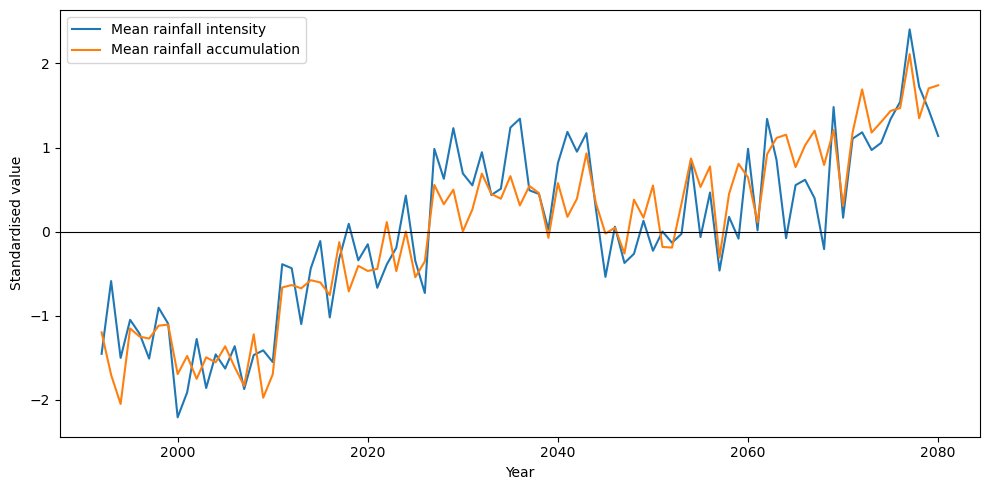

In [78]:
from scipy.stats import zscore

intensity_z = zscore(annual_mean_rainfall_intensity)
severity_z = zscore(annual_mean_rainfall_accum)

plt.figure(figsize=(10, 5))

plt.plot(
    annual_mean_rainfall_intensity.index,
    intensity_z,
    label="Mean rainfall intensity"
)

plt.plot(
    annual_mean_rainfall_accum.index,
    severity_z,
    label="Mean rainfall accumulation"
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Year")
plt.ylabel("Standardised value")
plt.legend()

plt.tight_layout()
plt.show()

### Do years with more events have more severe events?

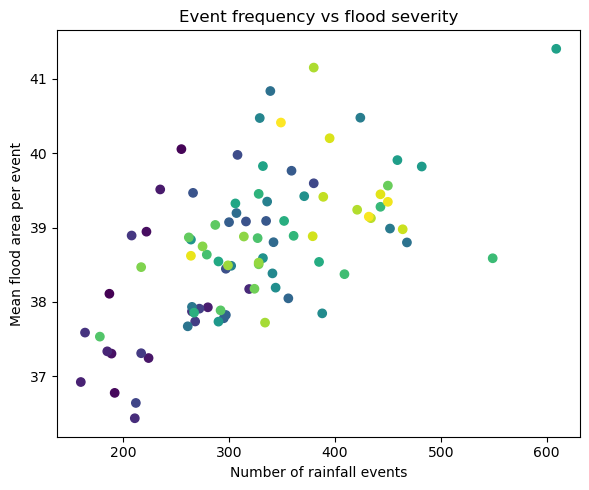

Spearman r = 0.590, p = 0.000


In [64]:
plt.figure(figsize=(6, 5))

plt.scatter(annual_counts, annual_mean_rainfall_intensity, c= annual_mean_rainfall_intensity.index)

plt.xlabel("Number of rainfall events")
plt.ylabel("Mean flood area per event")
plt.title("Event frequency vs flood severity")

plt.tight_layout()
plt.show()

# print(annual_counts.corr(annual_mean_rainfall_intensity))
from scipy.stats import spearmanr

r, p = spearmanr(annual_counts,annual_mean_rainfall_intensity)

print(f"Spearman r = {r:.3f}, p = {p:.3f}")

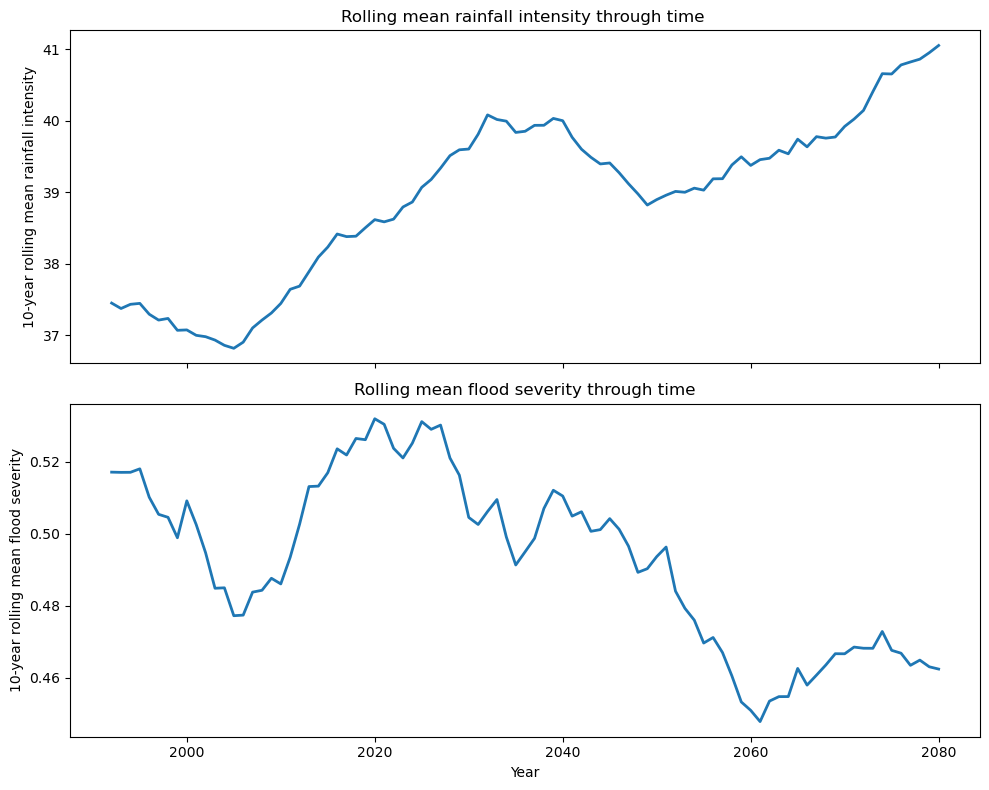

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Event frequency
axes[0].plot(rolling_rainfall_intensity.index,rolling_rainfall_intensity,linewidth=2)
axes[0].set_ylabel("10-year rolling mean rainfall intensity")
axes[0].set_title("Rolling mean rainfall intensity through time ")

# Severity per event
axes[1].plot(rolling_flood_severity.index,rolling_flood_severity,linewidth=2)
axes[1].set_ylabel("10-year rolling mean flood severity")
axes[1].set_xlabel("Year")
axes[1].set_title("Rolling mean flood severity through time")


plt.tight_layout()
plt.show()

In [ ]:
# fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig, ax = plt.subplots(figsize=(10, 3), sharex=True)

# Event frequency
ax.plot(annual_counts.index, annual_counts.values)
ax.set_ylabel("Number of rainfall events")
ax.set_title("Annual rainfall-event frequency")

# # Severity per event
# axes[1].plot(annual_mean_rainfall_severity.index, annual_mean_rainfall_severity.values)
# axes[1].set_ylabel("Mean maximum rainfall intensity")
# axes[1].set_xlabel("Year")
# axes[1].set_title("Mean rainfall intensity per rainfall event")

# # Severity per event
# axes[2].plot(annual_mean_flood_severity.index, annual_mean_flood_severity.values)
# axes[2].set_ylabel("Mean 10 cm flood area")
# axes[2].set_xlabel("Year")
# axes[2].set_title("Mean flood severity per rainfall event")

plt.tight_layout()
plt.show()

In [53]:
df_A = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] >= 3]
df_B = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=1) & (rainfall_events_all_df['hc_at_peak'] < 3)]
df_C = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.6) & (rainfall_events_all_df['hc_at_peak'] < 1)]
df_D = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.3) & (rainfall_events_all_df['hc_at_peak'] < 0.6)]
df_E = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.3]

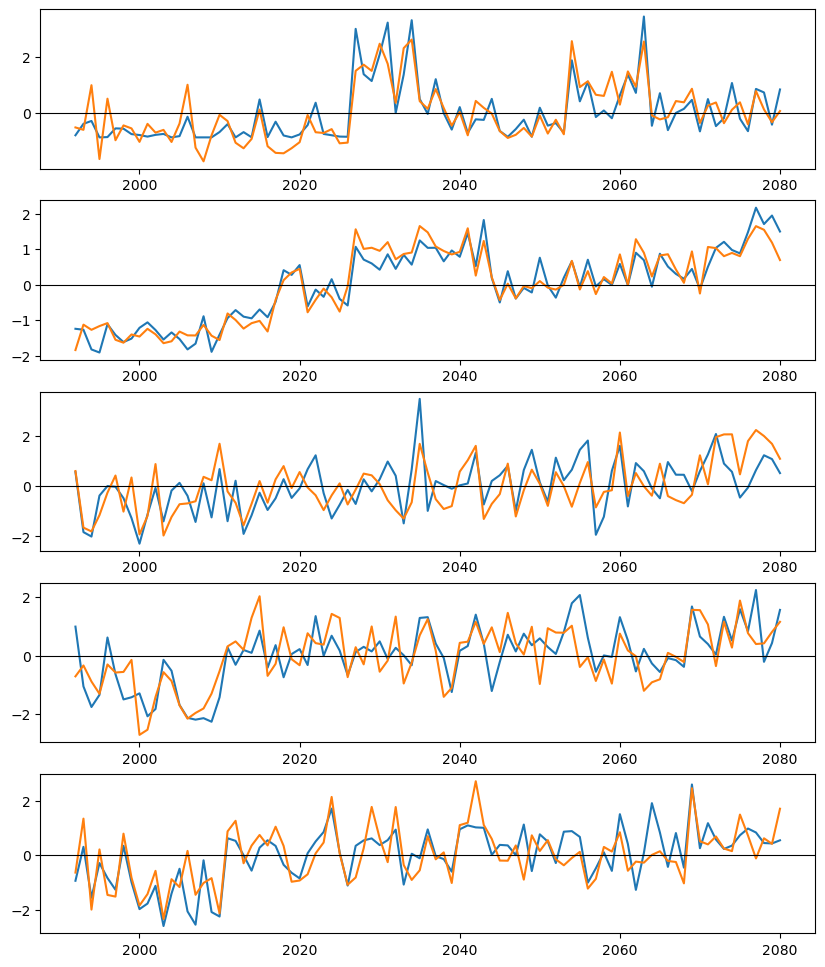

In [54]:
df_A = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] >= 3]
df_B = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=1) & (rainfall_events_all_df['hc_at_peak'] < 3)]
df_C = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.6) & (rainfall_events_all_df['hc_at_peak'] < 1)]
df_D = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.3) & (rainfall_events_all_df['hc_at_peak'] < 0.6)]
df_E = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.3]

from scipy.stats import zscore

fig, axs =plt.subplots(nrows=5, figsize=(10, 12))
for num, df in enumerate([df_A, df_B, df_C, df_D, df_E]):

    annual_mean_flood_severity = (df.groupby("start_year", observed=True)["10cm_volume"].mean())
    annual_mean_rainfall_intensity= (df.groupby("start_year", observed=True)["max_precip"].mean())
    annual_counts = (df.groupby(["start_year"],observed=True)).size()

    intensity_z = zscore(annual_mean_rainfall_intensity)
    severity_z = zscore(annual_mean_flood_severity)
    
    axs[num].plot(annual_mean_flood_severity.index, severity_z,label="Mean flood severity")
    axs[num].plot(annual_mean_rainfall_intensity.index,intensity_z,label="Mean rainfall severity")
    axs[num].axhline(0, color="black", linewidth=0.8)
    
#     axs[num].set_title()


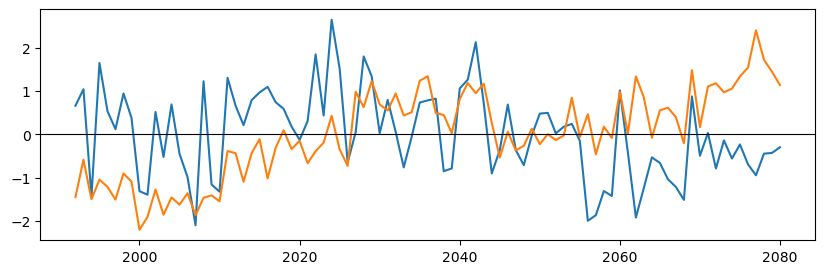

In [7]:
fig, ax =plt.subplots(figsize=(10, 3))
df=rainfall_events_all_df
annual_mean_flood_severity = (df.groupby("start_year", observed=True)["10cm_volume"].mean())
annual_mean_rainfall_intensity= (df.groupby("start_year", observed=True)["max_precip"].mean())
annual_counts = (df.groupby(["start_year"],observed=True)).size()
annual_severity = (df.groupby(["start_year"], observed=True)["10cm_area"].sum())

intensity_z = zscore(annual_mean_rainfall_intensity)
severity_z = zscore(annual_mean_flood_severity)

ax.plot(annual_mean_flood_severity.index, severity_z,label="Mean flood severity")
ax.plot(annual_mean_rainfall_intensity.index,intensity_z,label="Mean rainfall severity")
ax.axhline(0, color="black", linewidth=0.8)

In [19]:
rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 0.5, 1.1, 3, float('inf')],labels=['E', 'D', 'C', 'B', 'A'], right=False, include_lowest=True)

In [32]:
ssummary = (rainfall_events_all_df
    .groupby(["HC_status", "accum_bin"], observed=True)["10cm_area"]
    .sum())
ssummary

HC_status  accum_bin     
E          (30.0, 40.0]       1359.495877
           (40.0, 70.0]       7745.258570
           (70.0, 100.0]      3736.281539
           (100.0, 150.0]     2023.013666
           (150.0, 200.0]      274.745695
           (200.0, inf]         10.234800
D          (30.0, 40.0]       2195.209766
           (40.0, 70.0]      13648.625781
           (70.0, 100.0]      7112.941080
           (100.0, 150.0]     2675.185155
           (150.0, 200.0]      452.960993
           (200.0, inf]         98.324099
C          (30.0, 40.0]        139.303798
           (40.0, 70.0]       2262.615266
           (70.0, 100.0]      2066.871568
           (100.0, 150.0]     1511.778575
           (150.0, 200.0]      478.803592
           (200.0, inf]        448.672493
B          (30.0, 40.0]          2.358900
           (40.0, 70.0]        188.225097
           (70.0, 100.0]       363.394794
           (100.0, 150.0]      478.438192
           (150.0, 200.0]      219.046496
        

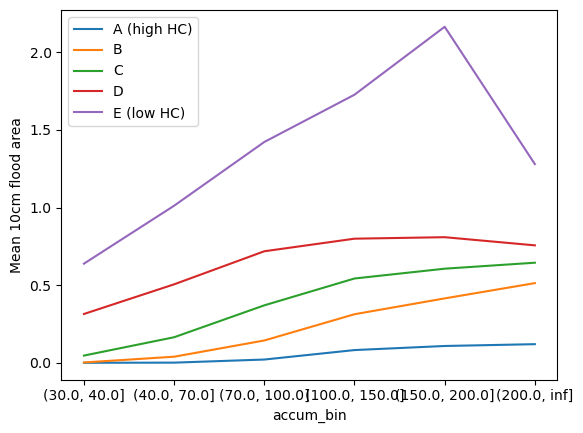

In [26]:
rainfall_events_all_df["accum_bin"] = pd.cut(rainfall_events_all_df["total_acc"],
    bins=[0, 10, 20, 30, 40, 70, 100, 150, 200, np.inf])

summary = (rainfall_events_all_df
    .groupby(["HC_status", "accum_bin"], observed=True)["10cm_area"]
    .mean())


fig,ax=plt.subplots()
summary['A'].plot(ax=ax, label='A (high HC)')
summary['B'].plot(ax=ax,  label='B')
summary['C'].plot(ax=ax,  label='C')
summary['D'].plot(ax=ax,  label='D')
summary['E'].plot(ax=ax,  label='E (low HC)')
ax.set_ylabel("Mean 10cm flood area")
ax.legend()

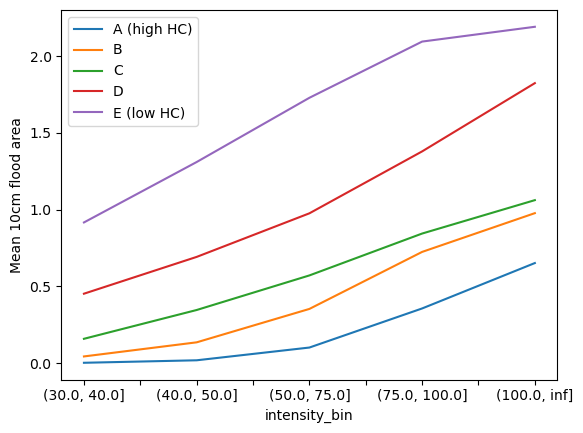

In [28]:
rainfall_events_all_df["intensity_bin"] = pd.cut(rainfall_events_all_df["max_precip"],
    bins=[0, 10, 20, 30, 40, 50, 75, 100, np.inf])

summary = (rainfall_events_all_df
    .groupby(["HC_status", "intensity_bin"], observed=True)["10cm_area"]
    .mean())


fig,ax=plt.subplots()
summary['A'].plot(ax=ax, label='A (high HC)')
summary['B'].plot(ax=ax,  label='B')
summary['C'].plot(ax=ax,  label='C')
summary['D'].plot(ax=ax,  label='D')
summary['E'].plot(ax=ax,  label='E (low HC)')
ax.set_ylabel("Mean 10cm flood area")
ax.legend()

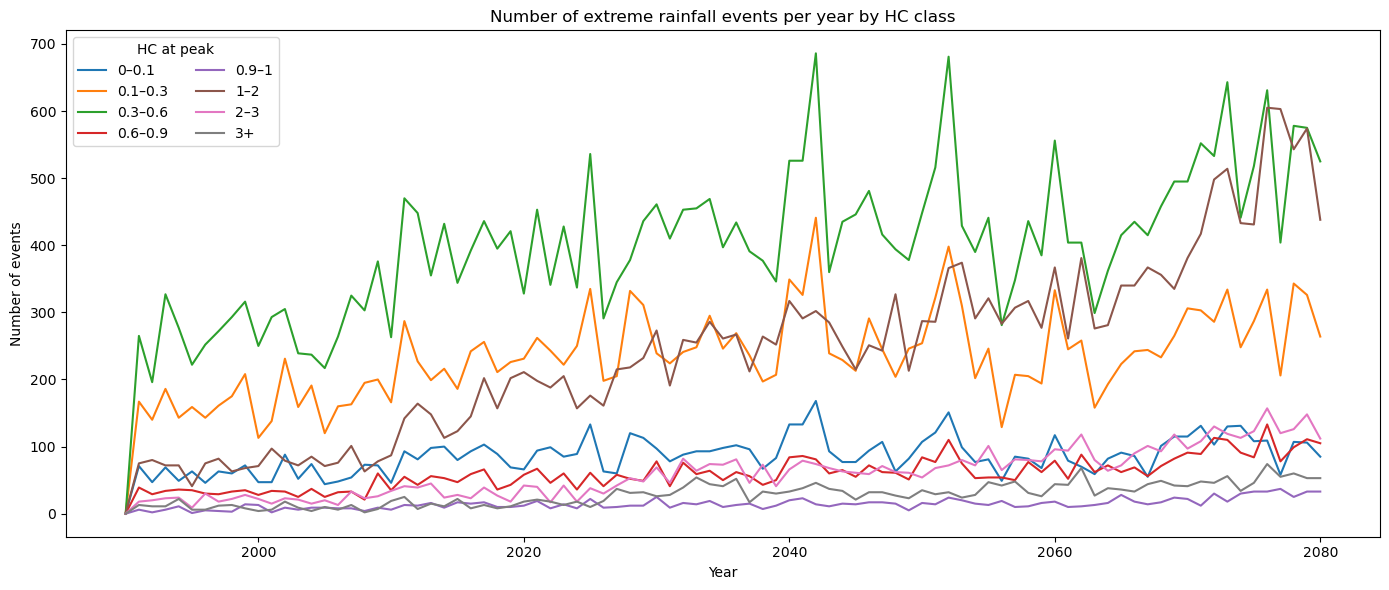

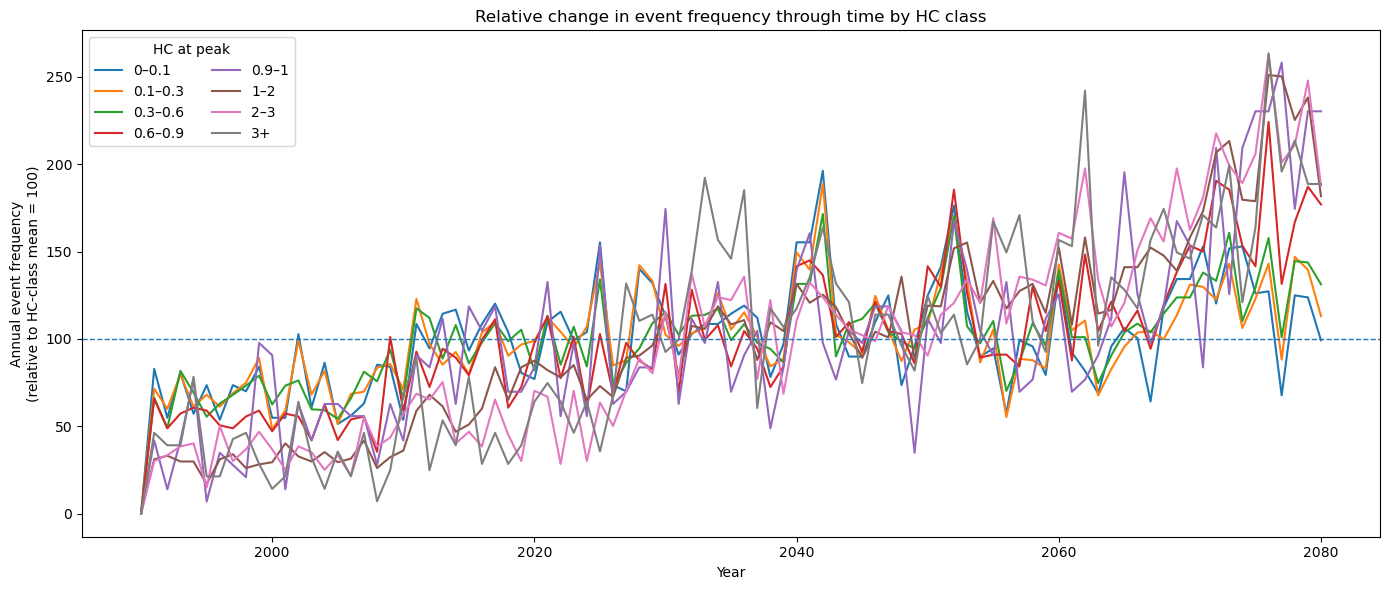

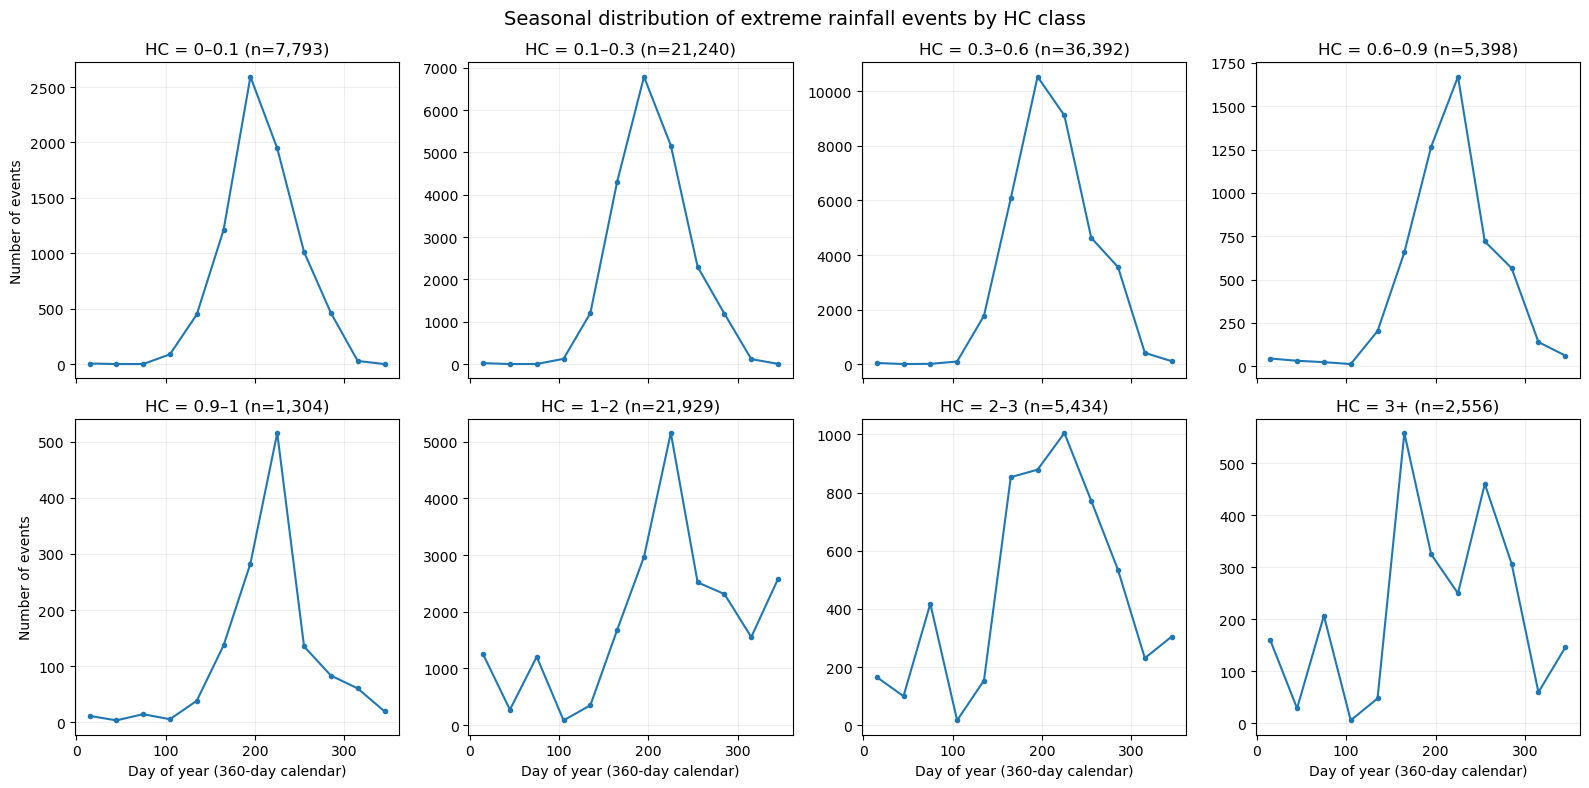

In [3]:
df = rainfall_events_all_df.copy()

# =========================================================
# 1. Define the same HC classes used in your analysis
# =========================================================

hc_bins = [-np.inf, 0.1, 0.3, 0.6, 0.9, 1, 2, 3, np.inf]

hc_labels = ["0–0.1","0.1–0.3","0.3–0.6","0.6–0.9","0.9–1","1–2","2–3","3+"]

df["HC_class"] = pd.cut(df["hc_at_peak"],bins=hc_bins,labels=hc_labels,right=False)

# Continuous representation of event time
df["event_time"] = (df["start_year"] + (df["day_360"] - 1) / 360)

# Remove rows without required information
df = df.dropna(subset=["start_year", "day_360", "HC_class"])

# =========================================================
# 2. Annual event counts
# =========================================================

annual_counts = (df.groupby(["start_year", "HC_class"],observed=True)
    .size()
    .unstack(fill_value=0))

# Make sure all HC classes are present as columns
annual_counts = annual_counts.reindex(columns=hc_labels,fill_value=0)

# =========================================================
# PLOT 1
# Raw number of events per year
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(annual_counts.index,annual_counts[hc],label=hc,linewidth=1.5)

ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.set_title("Number of extreme rainfall events per year by HC class")
ax.legend(title="HC at peak", ncol=2)

plt.tight_layout()
plt.show()

# =========================================================
# 3. Normalised annual event frequency
# =========================================================

# Calculate each class's mean annual event count
# and express each year relative to that mean.
#
# 100 = typical annual frequency for that HC class
# >100 = more events than typical
# <100 = fewer events than typical

annual_index = (annual_counts / annual_counts.mean(axis=0) * 100)

# =========================================================
# PLOT 2
# Relative change through time
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(annual_index.index,annual_index[hc],label=hc,linewidth=1.5)

ax.axhline(100,linestyle="--",linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Annual event frequency\n(relative to HC-class mean = 100)")
ax.set_title("Relative change in event frequency through time by HC class")

ax.legend(title="HC at peak", ncol=2)

plt.tight_layout()
plt.show()


# =========================================================
# 4. Seasonal event frequency
# =========================================================

# Bin the 360-day year into 30-day periods

bin_width = 30
bin_edges = np.arange(0,360 + bin_width,bin_width)
bin_centers = (bin_edges[:-1]+ bin_width / 2)
df["season_bin"] = pd.cut(df["day_360"],bins=bin_edges,labels=bin_centers,include_lowest=True)

# Count events by HC class and seasonal bin
seasonal_counts = (df.groupby(["HC_class", "season_bin"], observed=True)
    .size()
    .unstack(fill_value=0))
seasonal_counts = seasonal_counts.reindex(index=hc_labels, columns=bin_centers, fill_value=0)


# =========================================================
# PLOT 3
# Seasonal distribution by HC class
# =========================================================

fig, axes = plt.subplots(2,4,figsize=(16, 8),sharex=True,sharey=False)

axes = axes.flatten()

for ax, hc in zip(axes, hc_labels):
    values = seasonal_counts.loc[hc]
    ax.plot(bin_centers,values,marker="o",markersize=3,linewidth=1.5)
    ax.set_title(f"HC = {hc} (n={len(df[df['HC_class'] == hc]):,})")
    ax.grid(alpha=0.2)

for ax in axes[4:]:
    ax.set_xlabel("Day of year (360-day calendar)")

for ax in axes[::4]:
    ax.set_ylabel("Number of events")

fig.suptitle("Seasonal distribution of extreme rainfall events by HC class", fontsize=14)

plt.tight_layout()
plt.show()

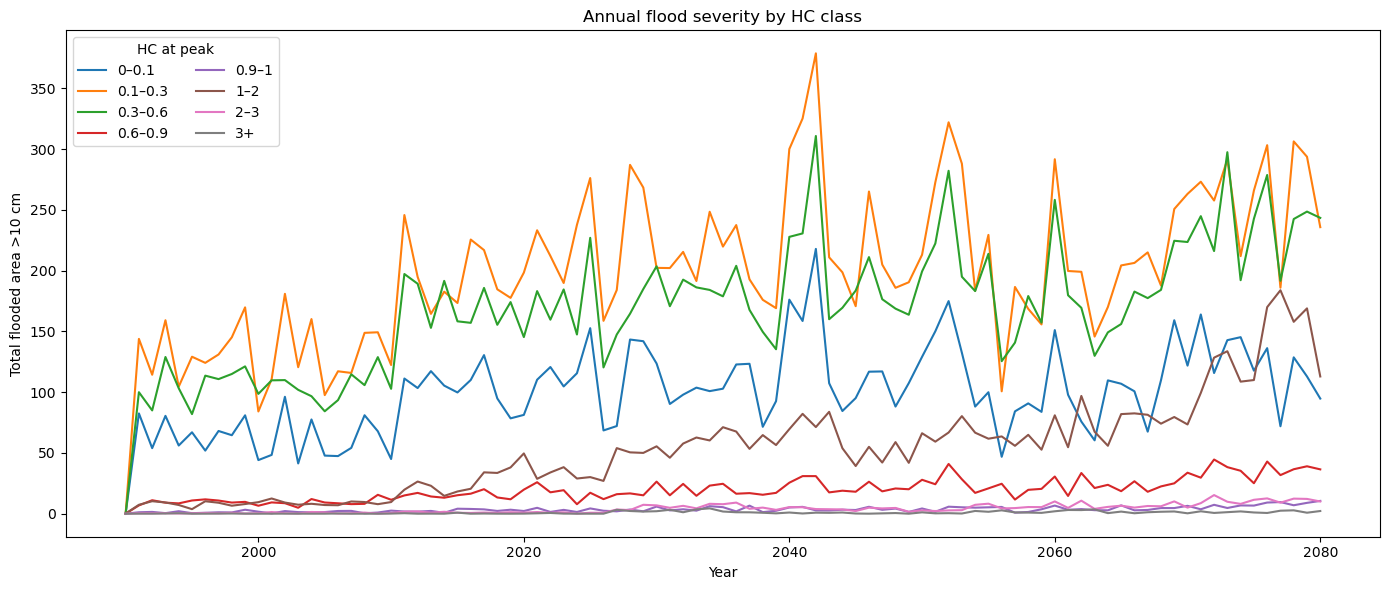

In [15]:

# =========================================================
# 1. Define HC classes
# =========================================================

hc_bins = [-np.inf, 0.1, 0.3, 0.6, 0.9, 1, 2, 3, np.inf]

hc_labels = [
    "0–0.1",
    "0.1–0.3",
    "0.3–0.6",
    "0.6–0.9",
    "0.9–1",
    "1–2",
    "2–3",
    "3+"
]

df["HC_class"] = pd.cut(
    df["hc_at_peak"],
    bins=hc_bins,
    labels=hc_labels,
    right=False
)

# Remove rows without required information
df = df.dropna(
    subset=["start_year", "day_360", "HC_class", "10cm_area"]
)

# =========================================================
# 2. Annual flood severity
# =========================================================

# Total flooded area produced by events in each year
annual_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .sum()
    .unstack(fill_value=0)
)

annual_severity = annual_severity.reindex(
    columns=hc_labels,
    fill_value=0
)

# =========================================================
# PLOT 1
# Total annual flooded area
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_severity.index,
        annual_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Total flooded area >10 cm")
ax.set_title(
    "Annual flood severity by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

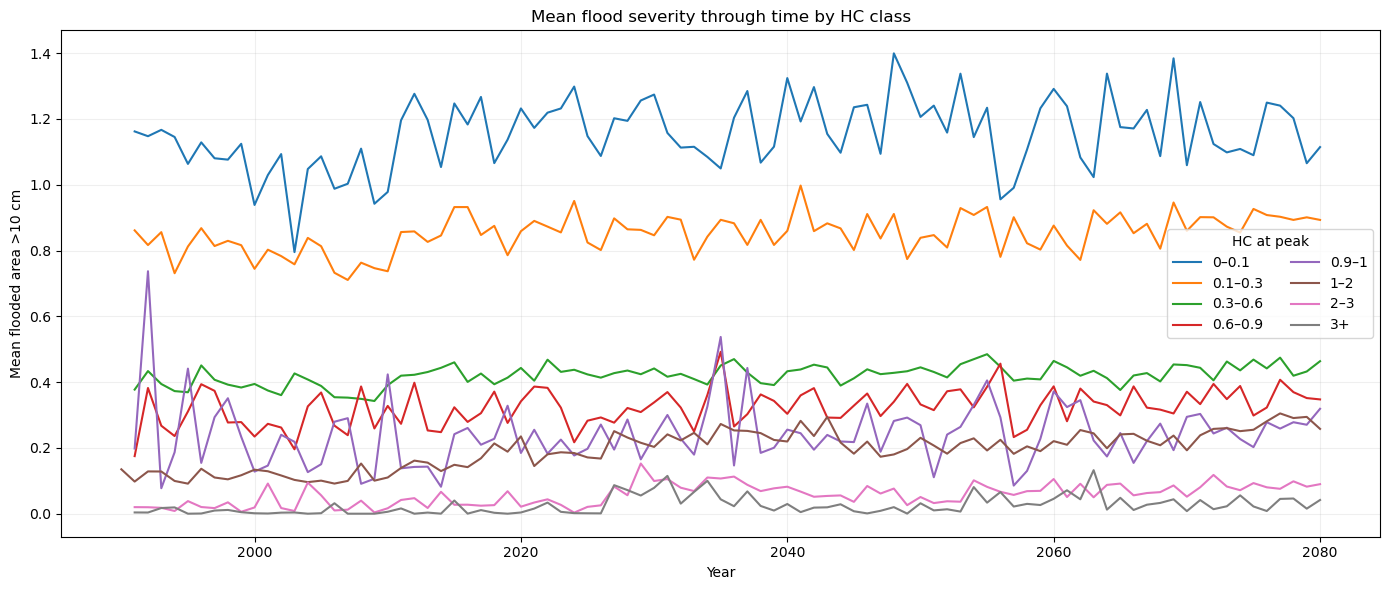

In [37]:
annual_mean_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .mean()
    .unstack()
)

annual_mean_severity = annual_mean_severity.reindex(
    columns=hc_labels
)


fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_mean_severity.index,
        annual_mean_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Mean flooded area >10 cm")
ax.set_title(
    "Mean flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

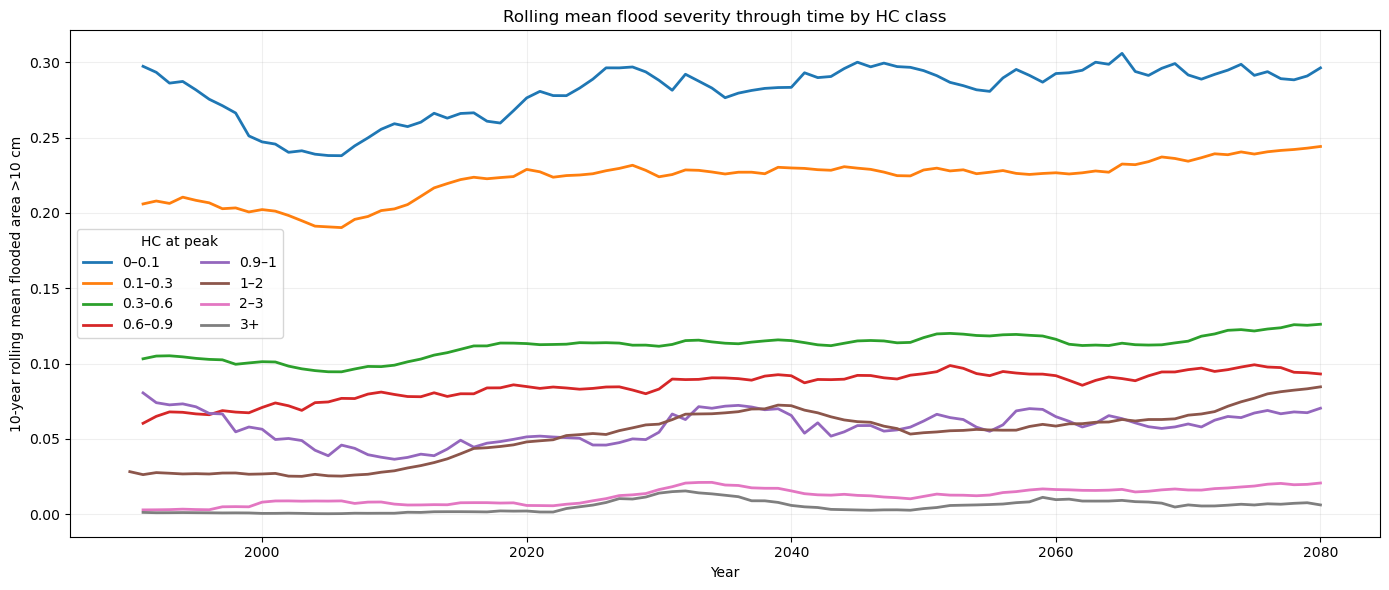

In [34]:
# 10-year rolling mean
rolling_severity = annual_mean_severity.rolling(
    window=10,
    center=True,
    min_periods=5
).mean()

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        rolling_severity.index,
        rolling_severity[hc],
        label=hc,
        linewidth=2
    )

ax.set_xlabel("Year")
ax.set_ylabel("10-year rolling mean flooded area >10 cm")
ax.set_title(
    "Rolling mean flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

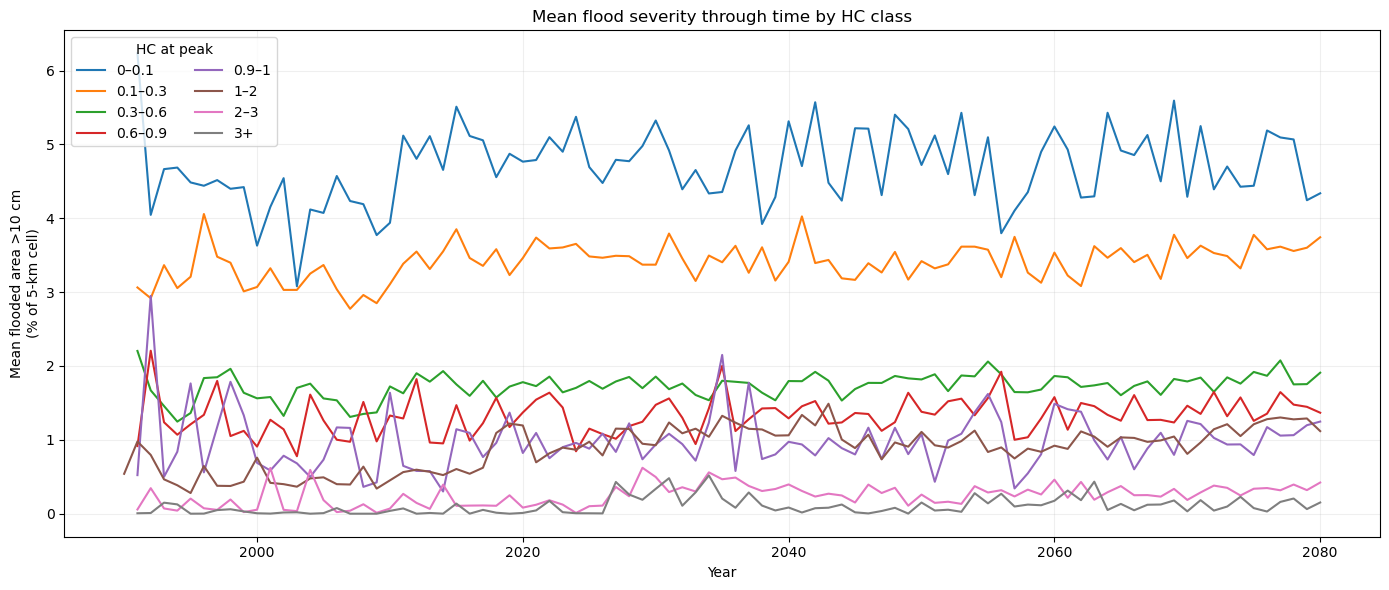

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = rainfall_events_all_df.copy()

# =========================================================
# 1. HC classes
# =========================================================

hc_bins = [-np.inf, 0.1, 0.3, 0.6, 0.9, 1, 2, 3, np.inf]

hc_labels = [
    "0–0.1",
    "0.1–0.3",
    "0.3–0.6",
    "0.6–0.9",
    "0.9–1",
    "1–2",
    "2–3",
    "3+"
]

df["HC_class"] = pd.cut(
    df["hc_at_peak"],
    bins=hc_bins,
    labels=hc_labels,
    right=False
)

# =========================================================
# 2. Flood severity for each event
# =========================================================

CELL_AREA = 25  # km²

df["flood_percent"] = (
    df["10cm_area"] / CELL_AREA * 100
)

# =========================================================
# 3. Mean severity for each cell in each year
# =========================================================

cell_year_severity = (
    df.groupby(
        ["start_year", "HC_class", "event_num"],
        observed=True
    )["flood_percent"]
    .mean()
    .reset_index()
)

# =========================================================
# 4. Average equally across cells within each HC class
# =========================================================

annual_severity = (
    cell_year_severity
    .groupby(
        ["start_year", "HC_class"],
        observed=True
    )["flood_percent"]
    .mean()
    .unstack()
)

annual_severity = annual_severity.reindex(
    columns=hc_labels
)

# =========================================================
# 5. Plot
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:

    ax.plot(
        annual_severity.index,
        annual_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")

ax.set_ylabel(
    "Mean flooded area >10 cm\n"
    "(% of 5-km cell)"
)

ax.set_title(
    "Mean flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

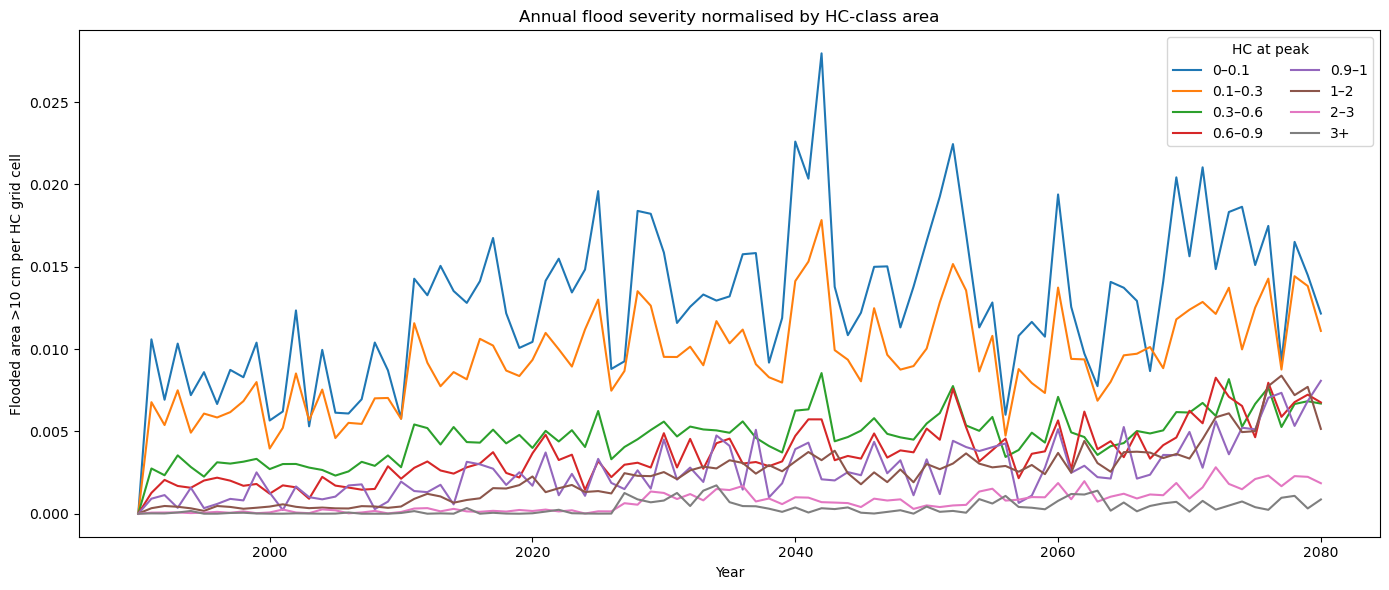

In [22]:
# Number of grid cells in each HC class
n_cells = df.groupby("HC_class", observed=True).size()

# Annual total flooded area
annual_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .sum()
    .unstack(fill_value=0)
)

annual_severity = annual_severity.reindex(
    columns=hc_labels,
    fill_value=0
)

# Normalise by number of cells in each HC class
annual_severity_per_cell = annual_severity.div(
    n_cells,
    axis="columns"
)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_severity_per_cell.index,
        annual_severity_per_cell[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Flooded area >10 cm per HC grid cell")
ax.set_title(
    "Annual flood severity normalised by HC-class area"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

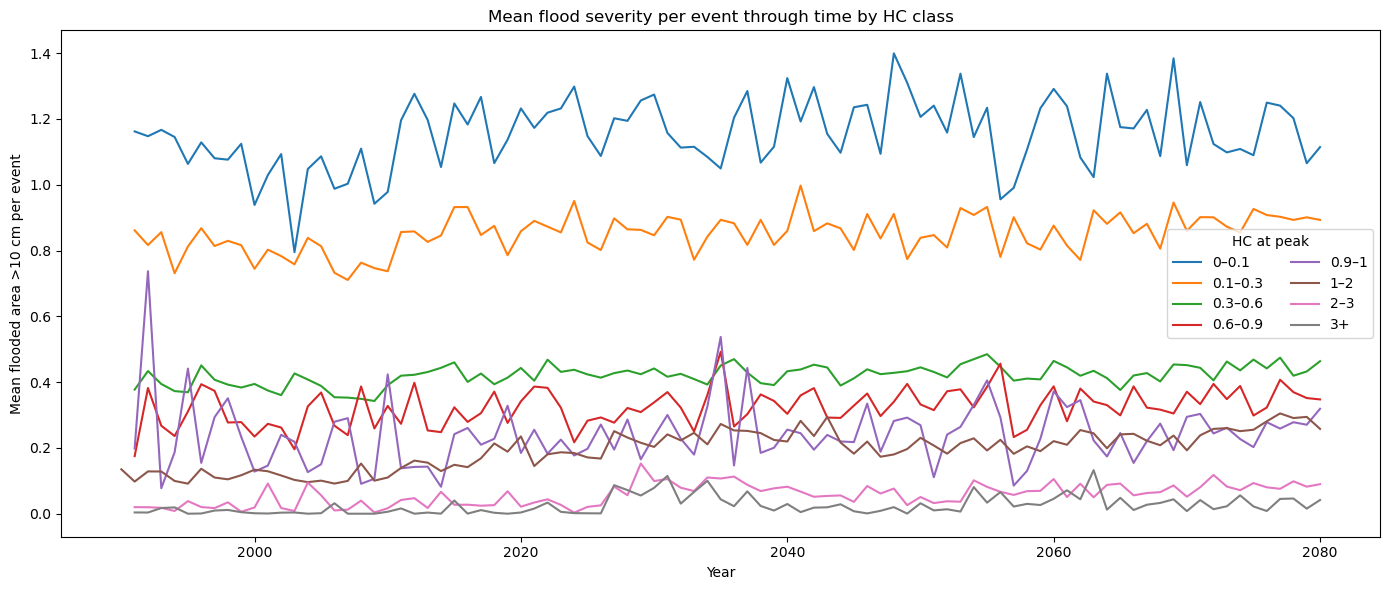

In [17]:
annual_mean_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .mean()
    .unstack()
)

annual_mean_severity = annual_mean_severity.reindex(
    columns=hc_labels
)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_mean_severity.index,
        annual_mean_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Mean flooded area >10 cm per event")
ax.set_title(
    "Mean flood severity per event through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

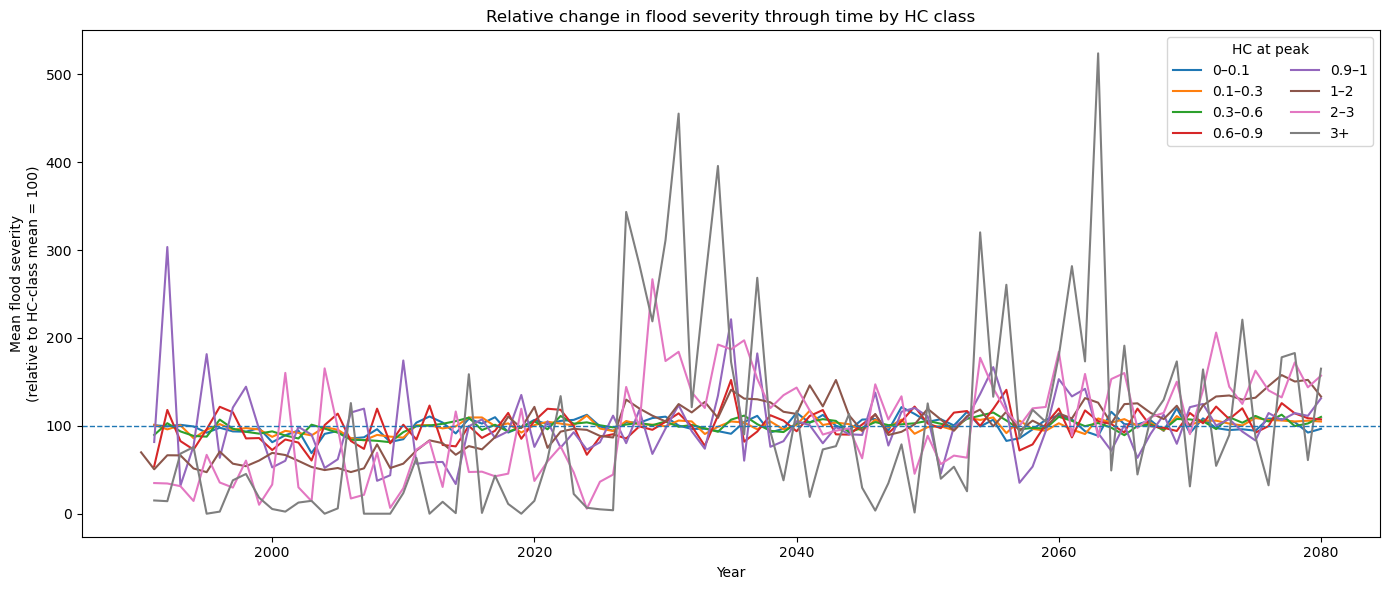

In [18]:
severity_index = (
    annual_mean_severity
    / annual_mean_severity.mean(axis=0)
    * 100
)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        severity_index.index,
        severity_index[hc],
        label=hc,
        linewidth=1.5
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Mean flood severity\n"
    "(relative to HC-class mean = 100)"
)

ax.set_title(
    "Relative change in flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

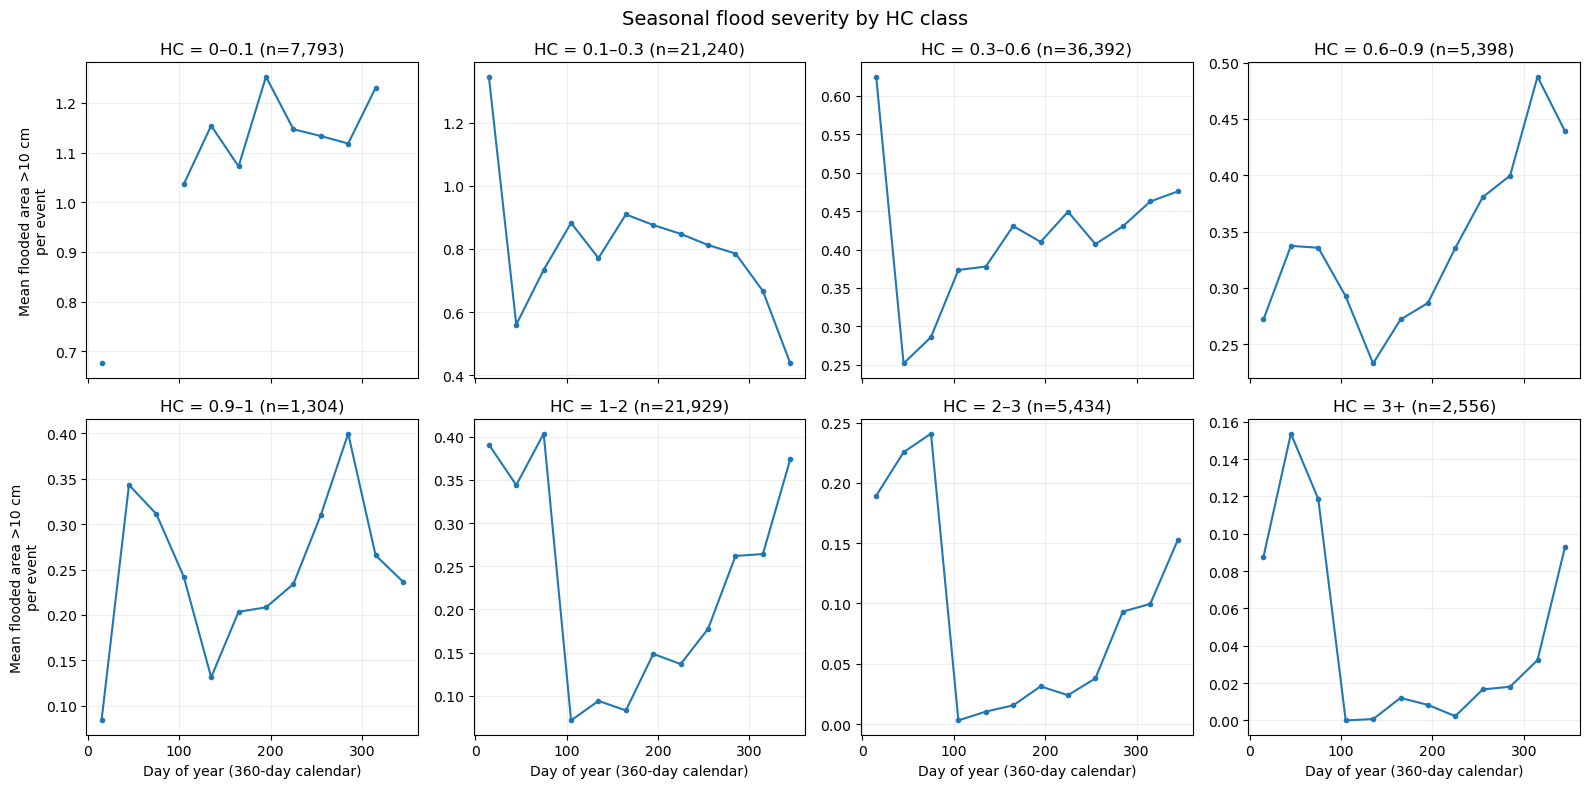

In [20]:
# =========================================================
# Seasonal flood severity
# =========================================================

bin_width = 30

bin_edges = np.arange(
    0,
    360 + bin_width,
    bin_width
)

bin_centers = (
    bin_edges[:-1] + bin_width / 2
)

df["season_bin"] = pd.cut(
    df["day_360"],
    bins=bin_edges,
    labels=bin_centers,
    include_lowest=True
)

# Mean flooded area per event
seasonal_severity = (
    df.groupby(
        ["HC_class", "season_bin"],
        observed=True
    )["10cm_area"]
    .mean()
    .unstack()
)

seasonal_severity = seasonal_severity.reindex(
    index=hc_labels,
    columns=bin_centers
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, hc in zip(axes, hc_labels):

    values = seasonal_severity.loc[hc]

    ax.plot(
        bin_centers,
        values,
        marker="o",
        markersize=3,
        linewidth=1.5
    )

    n = len(df[df["HC_class"] == hc])

    ax.set_title(
        f"HC = {hc} (n={n:,})"
    )

    ax.grid(alpha=0.2)

for ax in axes[4:]:
    ax.set_xlabel(
        "Day of year (360-day calendar)"
    )

for ax in axes[::4]:
    ax.set_ylabel(
        "Mean flooded area >10 cm\nper event"
    )

fig.suptitle(
    "Seasonal flood severity by HC class",
    fontsize=14
)

plt.tight_layout()
plt.show()

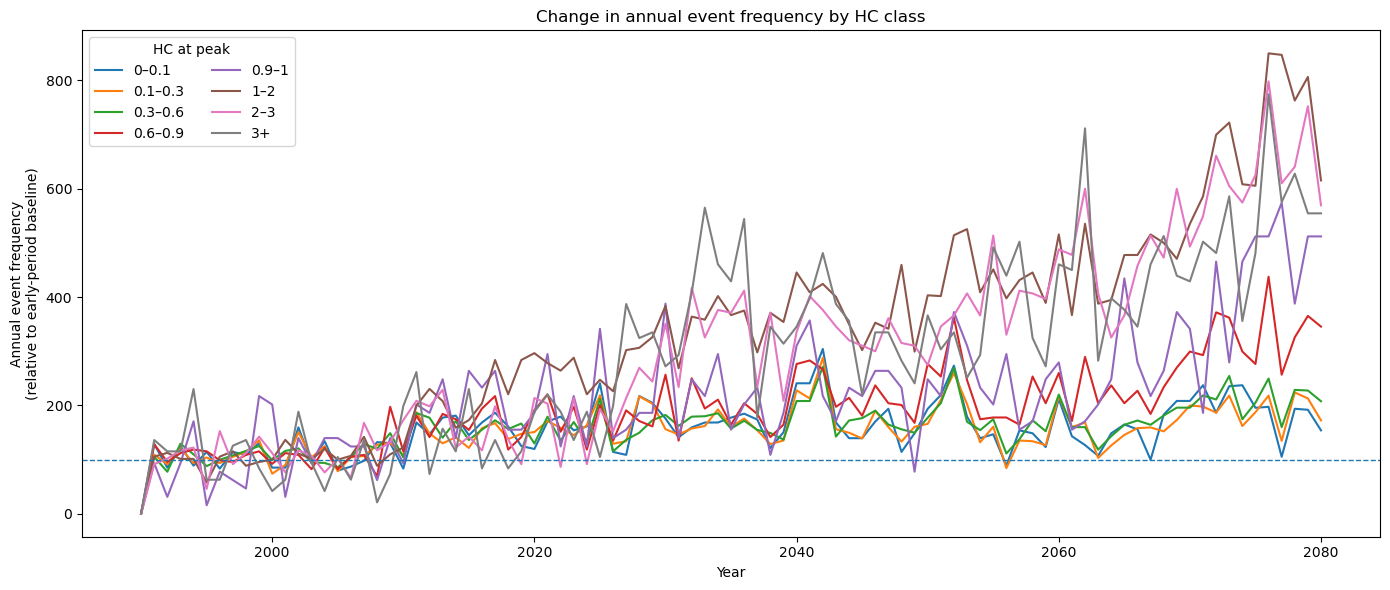

In [4]:
# ---------------------------------------------------------
# Index relative to early-simulation baseline
# ---------------------------------------------------------

years = np.sort(annual_counts.index)

n_baseline = max(1, int(len(years) * 0.2))

baseline_years = years[:n_baseline]

baseline = annual_counts.loc[baseline_years].mean()

annual_index_baseline = ( annual_counts / baseline* 100)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot( annual_index_baseline.index, annual_index_baseline[hc], label=hc, linewidth=1.5)

# 100 = baseline period
ax.axhline(100,linestyle="--",linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Annual event frequency\n(relative to early-period baseline)")

ax.set_title("Change in annual event frequency by HC class")

ax.legend(title="HC at peak",ncol=2)

plt.tight_layout()
plt.show()

HC_class
0–0.1       78.269618
0.1–0.3     73.920929
0.3–0.6     92.835165
0.6–0.9    188.482633
0.9–1      275.862069
1–2        503.590945
2–3        456.779661
3+         385.465116
dtype: float64


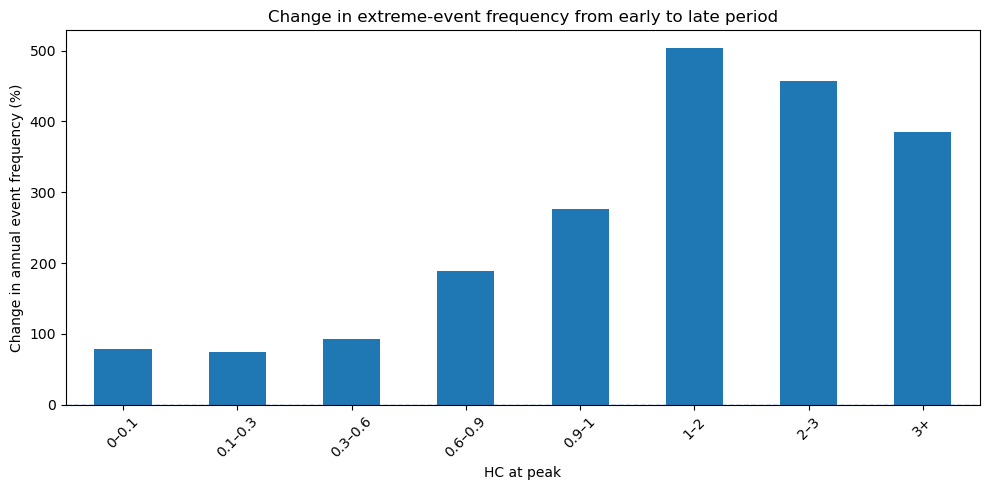

In [11]:
years = np.sort(annual_counts.index)

n_period = max(1, int(len(years) * 0.2))

early_years = years[:n_period]
late_years = years[-n_period:]

early_mean = annual_counts.loc[early_years].mean()
late_mean = annual_counts.loc[late_years].mean()

percentage_change = ((late_mean - early_mean) / early_mean * 100)

print(percentage_change)

fig, ax = plt.subplots(figsize=(10, 5))

percentage_change.plot(kind="bar",ax=ax)

ax.axhline(0,linestyle="--",linewidth=1)

ax.set_xlabel("HC at peak")
ax.set_ylabel("Change in annual event frequency (%)")
ax.set_title("Change in extreme-event frequency from early to late period")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
comparison = pd.DataFrame({
    "early_mean_events_per_year": early_mean,
    "late_mean_events_per_year": late_mean,
    "absolute_change": late_mean - early_mean,
    "percentage_change": percentage_change})

print(comparison)

          early_mean_events_per_year  late_mean_events_per_year  \
HC_class                                                          
0–0.1                      55.222222                  98.444444   
0.1–0.3                   153.166667                 266.388889   
0.3–0.6                   252.777778                 487.444444   
0.6–0.9                    30.388889                  87.666667   
0.9–1                       6.444444                  24.222222   
1–2                        71.166667                 429.555556   
2–3                        19.666667                 109.500000   
3+                          9.555556                  46.388889   

          absolute_change  percentage_change  
HC_class                                      
0–0.1           43.222222          78.269618  
0.1–0.3        113.222222          73.920929  
0.3–0.6        234.666667          92.835165  
0.6–0.9         57.277778         188.482633  
0.9–1           17.777778         275.862069  


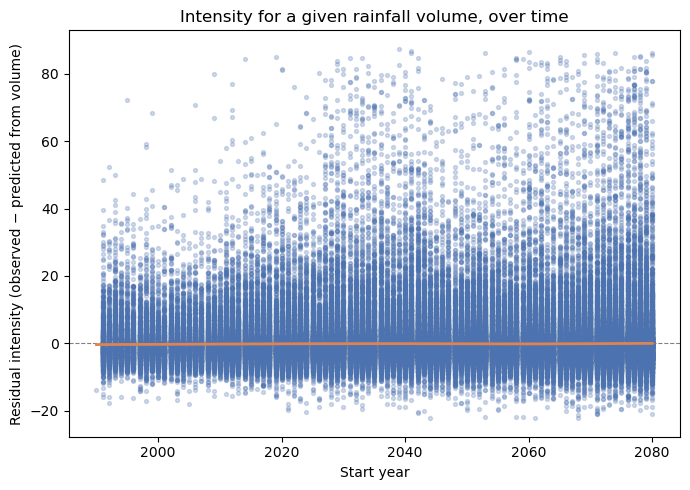

Mann-Kendall (tau=0.016, p=0.0000)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

df = rainfall_events_all_df.copy()
df['log_acc'] = np.log(df['total_acc'])

# --- 1. fit intensity ~ volume once, pooled across all years ---
sub = df.sort_values('log_acc')
fitted = lowess(sub['max_precip'], sub['log_acc'], frac=0.4, return_sorted=False)
df.loc[sub.index, 'pred_intensity'] = fitted
df['residual_intensity'] = df['max_precip'] - df['pred_intensity']

# --- 2. residual over time ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.scatter(df['start_year'], df['residual_intensity'], s=8, alpha=0.25, color='#4C72B0')

trend = lowess(df['residual_intensity'], df['start_year'], frac=0.5)
ax.plot(trend[:, 0], trend[:, 1], color='#DD8452', lw=2)

ax.set_xlabel('Start year')
ax.set_ylabel('Residual intensity (observed − predicted from volume)')
ax.set_title('Intensity for a given rainfall volume, over time')
plt.tight_layout()
plt.show()

# --- 3. formal trend test on the residual ---
tau, p = stats.kendalltau(df['start_year'], df['residual_intensity'])
print(f"Mann-Kendall (tau={tau:.3f}, p={p:.4f})")

/tmp/ipykernel_638088/2852480131.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (vb, sub) in zip(axes, df.groupby('vol_bin')):


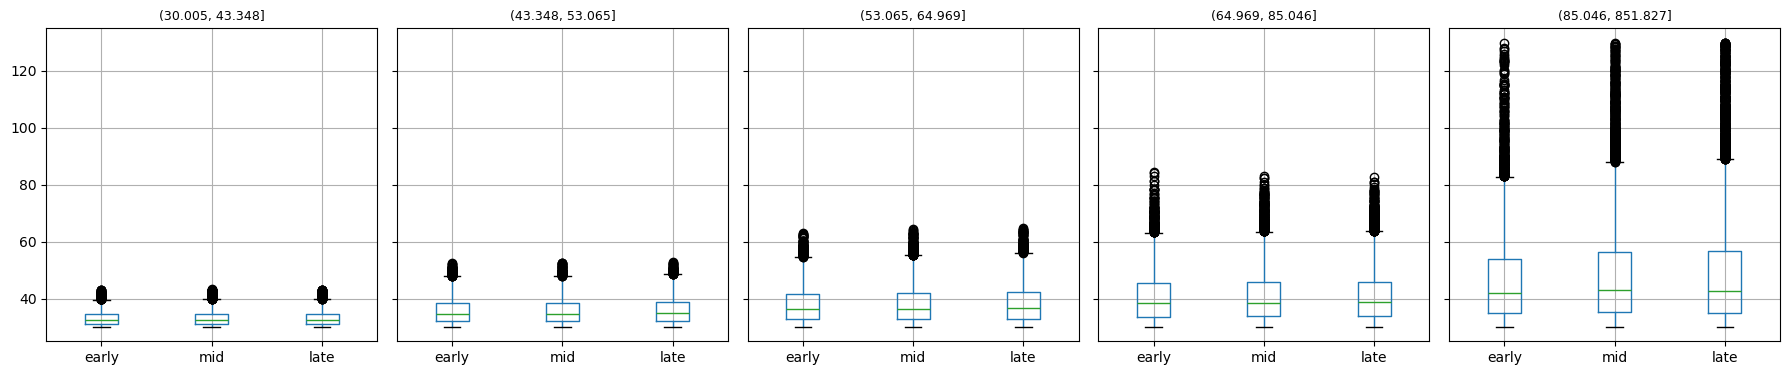

In [14]:
df['vol_bin'] = pd.qcut(df['total_acc'], q=5, duplicates='drop')
df['period'] = pd.qcut(df['start_year'], q=3, labels=['early','mid','late'])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, (vb, sub) in zip(axes, df.groupby('vol_bin')):
    sub.boxplot(column='max_precip', by='period', ax=ax)
    ax.set_title(f'{vb}', fontsize=9)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
rainfall_events_all_df["intensity_bin"] = pd.cut(
    rainfall_events_all_df["max_precip"],
    bins=[30, 40, 50, 75, 100, np.inf],
    labels=["30–40", "40–50", "50–75", "75–100", "100+"])

summary = (rainfall_events_all_df.groupby(["HC_status", "intensity_bin"], observed=True)["10cm_area"].mean().unstack())

fig, ax = plt.subplots(figsize=(8, 8))

colors = plt.cm.viridis(np.linspace(0, 1, 7))

for hc, color in zip(["A", "B", "C", "D", "E", "F", "G"], colors):
    ax.plot(summary.columns, summary.loc[hc], marker="o", linewidth=3, markersize=5, color=color, label=hc)

ax.set_xlabel("Maximum rainfall intensity (mm/hr)", fontsize=18)
ax.set_ylabel("Mean area flooded >10 cm", fontsize=18)
ax.set_title("Mean flooded area across rainfall intensity and \n hydraulic conductivity classes", fontsize=20, pad=12)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=11)

ax.legend(title="Region",labels=["A (highest)", "B", "C", "D", "E", "F", "G (lowest)"],
          bbox_to_anchor=(1.02, 0.5), loc="center left",frameon=False, fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()
plt.show()

In [ ]:
from scipy.stats import linregress

fig, axs = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)
axs = axs.flatten()

for i, hc in enumerate(["A", "B", "C", "D", "E", "F", "G"]):
    subset = rainfall_events_all_df[rainfall_events_all_df["HC_status"] == hc].dropna(subset=["max_precip", "10cm_area"])

    x = subset["max_precip"]
    y = subset["10cm_area"]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line

    axs[i].scatter(x, y, alpha=0.25, s=15)
    axs[i].plot(x_line, y_line, linewidth=2)

    axs[i].set_title(f"HC class {hc}")
    axs[i].text(0.05, 0.92, f"$R^2$ = {r_value**2:.2f}\np = {p_value:.3g}",
                transform=axs[i].transAxes, va="top")

    axs[i].grid(alpha=0.2)

axs[0].set_ylabel("Flooded area >10 cm")
axs[4].set_ylabel("Flooded area >10 cm")

for ax in axs[4:]:
    ax.set_xlabel("Maximum rainfall intensity (mm/hr)")

axs[7].axis("off")

fig.suptitle("Relationship between rainfall intensity and flooded area by HC class", fontsize=15)
fig.tight_layout()
plt.show()